In [40]:
# ===== Cell 1: imports & basic config =====
import os
from typing import Dict, List

import matplotlib.pyplot as plt

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from pycocotools.coco import COCO  # pip install pycocotools

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


# ===== Cell 2: PartImageNet paths =====
# EDIT this if your root is different
PARTIMAGENET_ROOT = "PartImageNet_Seg/PartImageNet"

TRAIN_JSON = os.path.join(PARTIMAGENET_ROOT, "annotations", "train", "train.json")
VAL_JSON   = os.path.join(PARTIMAGENET_ROOT, "annotations", "val",   "val.json")

IMG_ROOT_TRAIN = os.path.join(PARTIMAGENET_ROOT, "images", "train")
IMG_ROOT_VAL   = os.path.join(PARTIMAGENET_ROOT, "images", "val")

print("TRAIN_JSON =", TRAIN_JSON)
print("VAL_JSON   =", VAL_JSON)
print("IMG_ROOT_TRAIN =", IMG_ROOT_TRAIN)
print("IMG_ROOT_VAL   =", IMG_ROOT_VAL)


# ===== Cell 3: inspect COCO & derive parts / object classes =====
coco_train = COCO(TRAIN_JSON)

print("Number of images:", len(coco_train.getImgIds()))
print("Number of annotations:", len(coco_train.getAnnIds()))
print("Number of categories:", len(coco_train.getCatIds()))

cat_ids = coco_train.getCatIds()
cats = coco_train.loadCats(cat_ids)
print("Example category:", cats[0])

# Canonical parts = category "name"
CANONICAL_PARTS: List[str] = sorted({c["name"] for c in cats})
print("Number of canonical parts:", len(CANONICAL_PARTS))
print("First few parts:", CANONICAL_PARTS[:10])

# Object classes = category "supercategory" (e.g., 'Quadruped', 'Bird', ...)
obj_names: List[str] = sorted({c["supercategory"] for c in cats})
OBJ_NAME_TO_IDX: Dict[str, int] = {n: i for i, n in enumerate(obj_names)}

print("Number of object classes:", len(obj_names))
print("First few object classes:", list(OBJ_NAME_TO_IDX.items())[:10])

NUM_PARTS = len(CANONICAL_PARTS)
NUM_CLASSES = len(OBJ_NAME_TO_IDX)


# ===== Cell 4: full-image dataset (clean, robust) =====
class PartImageNetFullClean(Dataset):
    """
    Full-image PartImageNet_Seg dataset.

    Each sample:
        {
          "image":      FloatTensor 3 x H x W,
          "part_masks": Dict[str, FloatTensor 1 x H x W],
          "obj_label":  LongTensor scalar in [0, NUM_CLASSES),
          "obj_name":   str
        }
    """
    def __init__(self,
                 json_path: str,
                 img_root: str,
                 canonical_parts: List[str],
                 obj_name_to_idx: Dict[str, int],
                 transform=None):
        super().__init__()
        self.coco = COCO(json_path)
        self.img_root = img_root
        self.transform = transform
        self.canonical_parts = canonical_parts
        self.obj_name_to_idx = obj_name_to_idx

        self.cats = self.coco.loadCats(self.coco.getCatIds())
        self.part_name_to_cat_id: Dict[str, int] = {}
        for c in self.cats:
            name = c["name"]
            if name in canonical_parts:
                self.part_name_to_cat_id[name] = c["id"]

        if self.transform is None:
            self.transform = T.Compose([
                T.Resize((256, 256)),
                T.ToTensor(),
            ])

        all_img_ids = self.coco.getImgIds()
        self.samples = []
        skipped_no_file = 0
        skipped_no_ann  = 0
        skipped_no_obj  = 0

        for img_id in all_img_ids:
            info = self.coco.loadImgs(img_id)[0]
            fname = info["file_name"]  # e.g. "n02607072_498.JPEG"

            # Try both flat layout and wnid subfolder (ImageNet-style)
            cand1 = os.path.join(self.img_root, fname)
            wnid = fname.split("_")[0]
            cand2 = os.path.join(self.img_root, wnid, fname)

            if os.path.exists(cand1):
                img_path = cand1
            elif os.path.exists(cand2):
                img_path = cand2
            else:
                skipped_no_file += 1
                continue

            ann_ids = self.coco.getAnnIds(imgIds=[img_id])
            if len(ann_ids) == 0:
                skipped_no_ann += 1
                continue
            anns = self.coco.loadAnns(ann_ids)

            obj_names_in_image = set()
            for ann in anns:
                cat = self.coco.loadCats(ann["category_id"])[0]
                supercat = cat["supercategory"]
                obj_names_in_image.add(supercat)

            if len(obj_names_in_image) == 0:
                skipped_no_obj += 1
                continue

            obj_name = sorted(obj_names_in_image)[0]
            if obj_name not in self.obj_name_to_idx:
                skipped_no_obj += 1
                continue
            obj_label = self.obj_name_to_idx[obj_name]

            self.samples.append({
                "img_id": img_id,
                "img_path": img_path,
                "obj_name": obj_name,
                "obj_label": obj_label,
            })

        print(f"[PartImageNetFullClean] {json_path}")
        print(f"  #images in JSON   = {len(all_img_ids)}")
        print(f"  #images kept      = {len(self.samples)}")
        print(f"  #skipped (no file)= {skipped_no_file}")
        print(f"  #skipped (no ann) = {skipped_no_ann}")
        print(f"  #skipped (no obj) = {skipped_no_obj}")
        print(f"  #part categories used = {len(self.part_name_to_cat_id)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        rec = self.samples[idx]
        img_id = rec["img_id"]
        img_path = rec["img_path"]
        obj_name = rec["obj_name"]
        obj_label = rec["obj_label"]

        img = Image.open(img_path).convert("RGB")
        img_t = self.transform(img)  # 3 x H x W
        _, H, W = img_t.shape

        ann_ids = self.coco.getAnnIds(imgIds=[img_id])
        anns = self.coco.loadAnns(ann_ids)

        part_masks: Dict[str, torch.Tensor] = {}

        for ann in anns:
            cat = self.coco.loadCats(ann["category_id"])[0]
            part_name = cat["name"]
            if part_name not in self.canonical_parts:
                continue

            segm = ann.get("segmentation", None)
            if segm is None or (isinstance(segm, list) and len(segm) == 0):
                continue
            if not isinstance(segm, (list, dict)):
                continue

            try:
                mask_np = self.coco.annToMask(ann)  # H_orig x W_orig, {0,1}
            except Exception:
                continue

            mask_img = Image.fromarray((mask_np.astype(np.uint8) * 255))
            mask_img = mask_img.resize((W, H), resample=Image.NEAREST)
            mask_arr = np.array(mask_img)
            mask_t = torch.from_numpy(mask_arr).float()
            mask_t = (mask_t > 0).float().unsqueeze(0)  # 1 x H x W

            if part_name in part_masks:
                part_masks[part_name] = torch.maximum(part_masks[part_name], mask_t)
            else:
                part_masks[part_name] = mask_t

        return {
            "image": img_t,
            "part_masks": part_masks,
            "obj_label": torch.tensor(obj_label, dtype=torch.long),
            "obj_name": obj_name,
        }


# ===== Cell 5: collate & dataloaders =====
def collate_full(batch_list):
    images = torch.stack([b["image"] for b in batch_list], dim=0)
    labels = torch.stack([b["obj_label"] for b in batch_list], dim=0)
    obj_names = [b["obj_name"] for b in batch_list]

    all_part_names = set()
    for b in batch_list:
        all_part_names.update(b["part_masks"].keys())

    B, _, H, W = images.shape
    part_masks_batch: Dict[str, torch.Tensor] = {}
    for pname in all_part_names:
        masks = []
        for b in batch_list:
            if pname in b["part_masks"]:
                masks.append(b["part_masks"][pname])
            else:
                masks.append(torch.zeros(1, H, W, dtype=torch.float32))
        part_masks_batch[pname] = torch.stack(masks, dim=0)  # B x 1 x H x W

    return {
        "image": images,
        "part_masks": part_masks_batch,
        "obj_label": labels,
        "obj_name": obj_names,
    }

ds_tr_full = PartImageNetFullClean(
    json_path=TRAIN_JSON,
    img_root=IMG_ROOT_TRAIN,
    canonical_parts=CANONICAL_PARTS,
    obj_name_to_idx=OBJ_NAME_TO_IDX,
    transform=None,
)

ds_val_full = PartImageNetFullClean(
    json_path=VAL_JSON,
    img_root=IMG_ROOT_VAL,
    canonical_parts=CANONICAL_PARTS,
    obj_name_to_idx=OBJ_NAME_TO_IDX,
    transform=None,
)

BATCH_SIZE = 4
NUM_WORKERS = 4

train_loader = DataLoader(
    ds_tr_full,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_full,
)

val_loader = DataLoader(
    ds_val_full,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_full,
)

print("Train dataset size:", len(ds_tr_full))
print("Val dataset size:  ", len(ds_val_full))

# sanity check
batch = next(iter(train_loader))
print("Batch keys:", batch.keys())
print("image:", batch["image"].shape, batch["image"].dtype)
print("obj_label:", batch["obj_label"].shape, batch["obj_label"][:4])
print("obj_name:", batch["obj_name"][:4])
print("part_masks keys (sample):", list(batch["part_masks"].keys())[:10])
for pname, m in batch["part_masks"].items():
    print("  ", pname, m.shape)
    break


Using device: cuda
TRAIN_JSON = PartImageNet_Seg/PartImageNet/annotations/train/train.json
VAL_JSON   = PartImageNet_Seg/PartImageNet/annotations/val/val.json
IMG_ROOT_TRAIN = PartImageNet_Seg/PartImageNet/images/train
IMG_ROOT_VAL   = PartImageNet_Seg/PartImageNet/images/val
loading annotations into memory...
Done (t=0.59s)
creating index...
index created!
Number of images: 20481
Number of annotations: 95059
Number of categories: 40
Example category: {'id': 0, 'name': 'Quadruped Head', 'supercategory': 'Quadruped'}
Number of canonical parts: 40
First few parts: ['Aeroplane Body', 'Aeroplane Engine', 'Aeroplane Head', 'Aeroplane Tail', 'Aeroplane Wing', 'Bicycle Body', 'Bicycle Head', 'Bicycle Seat', 'Bicycle Tier', 'Biped Body']
Number of object classes: 11
First few object classes: [('Aeroplane', 0), ('Bicycle', 1), ('Biped', 2), ('Bird', 3), ('Boat', 4), ('Bottle', 5), ('Car', 6), ('Fish', 7), ('Quadruped', 8), ('Reptile', 9)]
loading annotations into memory...
Done (t=0.49s)
creati

In [41]:
# ===== Cell 6: CLIP text embeddings for parts =====
import clip  # pip install git+https://github.com/openai/CLIP.git

clip_model, _ = clip.load("RN50", device=device)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

with torch.no_grad():
    part_prompts = [f"the {name} of the object" for name in CANONICAL_PARTS]
    text_tokens = clip.tokenize(part_prompts).to(device)
    text_features = clip_model.encode_text(text_tokens).float()
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

T_part = text_features          # K x D_TEXT
D_TEXT = T_part.shape[1]

NUM_PARTS = len(CANONICAL_PARTS)
NUM_CLASSES = len(OBJ_NAME_TO_IDX)

print("T_part shape:", T_part.shape)
print("NUM_PARTS:", NUM_PARTS, "NUM_CLASSES:", NUM_CLASSES)


# ===== Cell 7: ResNet-50 backbone (visual) =====
from torchvision.models import resnet50, ResNet50_Weights

class ResNetBackbone(nn.Module):
    """
    Standard ResNet-50 backbone (ImageNet-pretrained) for visual features.
    Outputs:
      F_spatial: B x C x H' x W'
      g:         B x C (global pooled, L2-normalized)
    """
    def __init__(self):
        super().__init__()
        base = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        for p in base.parameters():
            p.requires_grad = False

        self.conv1 = base.conv1
        self.bn1   = base.bn1
        self.relu  = base.relu
        self.maxpool = base.maxpool
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.out_channels = 2048

    def forward(self, x: torch.Tensor):
        # x: B x 3 x H x W in [0,1]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)        # B x C x H' x W'

        g = x.mean(dim=[2, 3])    # B x C
        g = g.float()
        g = g / (g.norm(dim=-1, keepdim=True) + 1e-6)
        return x.float(), g


# ===== Cell 8: part segmentation head & masked tokens =====
class PartSegHead(nn.Module):
    def __init__(self, F_channels: int, text_dim: int, num_parts: int):
        super().__init__()
        self.proj = nn.Conv2d(F_channels, text_dim, kernel_size=1)
        self.smooth = nn.Conv2d(num_parts, num_parts, kernel_size=3,
                                padding=1, groups=num_parts)
        self.scale = nn.Parameter(torch.ones(1, num_parts, 1, 1))
        self.bias  = nn.Parameter(torch.zeros(1, num_parts, 1, 1))
        self.num_parts = num_parts
        self.text_dim  = text_dim

    def forward(self, F_spatial: torch.Tensor,
                T_part: torch.Tensor,
                out_size):
        B, C, H, W = F_spatial.shape
        K, D_t = T_part.shape

        V = self.proj(F_spatial)               # B x D_t x H x W
        V = V / (V.norm(dim=1, keepdim=True) + 1e-6)

        V_flat = V.view(B, D_t, H * W)
        S_flat = torch.einsum("bdn,kd->bkn", V_flat, T_part)
        S = S_flat.view(B, K, H, W)

        S_smooth = self.smooth(S)
        logits = self.scale * S_smooth + self.bias

        if out_size is not None:
            logits = F.interpolate(
                logits, size=out_size,
                mode="bilinear", align_corners=False
            )

        return logits  # B x K x H_out x W_out


def masked_part_tokens(F_spatial: torch.Tensor,
                       masks_logits: torch.Tensor,
                       eps: float = 1e-6) -> torch.Tensor:
    B, C, H, W = F_spatial.shape
    B2, K, Hm, Wm = masks_logits.shape
    assert B == B2

    if (Hm, Wm) != (H, W):
        masks_logits = F.interpolate(
            masks_logits, size=(H, W),
            mode="bilinear", align_corners=False
        )

    masks = torch.sigmoid(masks_logits)        # B x K x H x W
    F_flat = F_spatial.view(B, C, H * W)       # B x C x N
    masks_flat = masks.view(B, K, H * W)       # B x K x N

    num = torch.einsum("bkn,bcn->bkc", masks_flat, F_flat)  # B x K x C
    den = masks_flat.sum(dim=-1, keepdim=True) + eps        # B x K x 1

    tokens = num / den
    return tokens  # B x K x C


# ===== Cell 9: relative part graph =====
class RelativePartGraph(nn.Module):
    """
    Part graph with object-centered, relative geometry.

    Node features:
      - visual token z_k  (B x K x C)
      - text embedding t_k (K x D_text, broadcast to B)
      - node geom: (cx_norm, cy_norm, wx_norm, wy_norm)

    Edge features (for each pair i,j):
      - Δx_ij, Δy_ij, |Δx_ij|, |Δy_ij|, r_ij, cosθ_ij, sinθ_ij
    """
    def __init__(self,
                 token_dim: int,
                 text_dim: int,
                 geom_dim: int = 4,
                 hidden_dim: int = 256):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.node_mlp = nn.Sequential(
            nn.Linear(token_dim + text_dim + geom_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

        edge_feat_dim = 7
        self.msg_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

        self.upd_mlp = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

    def _node_geom(self, masks_logits: torch.Tensor) -> torch.Tensor:
        B, K, H, W = masks_logits.shape
        masks = torch.sigmoid(masks_logits)

        ys = torch.linspace(0.0, 1.0, H, device=masks.device).view(1, 1, H, 1)
        xs = torch.linspace(0.0, 1.0, W, device=masks.device).view(1, 1, 1, W)

        area = masks.sum(dim=(-2, -1), keepdim=True) + 1e-6

        cy = (masks * ys).sum(dim=(-2, -1), keepdim=True) / area
        cx = (masks * xs).sum(dim=(-2, -1), keepdim=True) / area

        wy = torch.sqrt(
            (masks * (ys - cy) ** 2).sum(dim=(-2, -1), keepdim=True) / area + 1e-6
        )
        wx = torch.sqrt(
            (masks * (xs - cx) ** 2).sum(dim=(-2, -1), keepdim=True) / area + 1e-6
        )

        cx = cx.squeeze(-1).squeeze(-1)
        cy = cy.squeeze(-1).squeeze(-1)
        wx = wx.squeeze(-1).squeeze(-1)
        wy = wy.squeeze(-1).squeeze(-1)

        cx_obj = cx.mean(dim=1, keepdim=True)
        cy_obj = cy.mean(dim=1, keepdim=True)

        cx_min, _ = cx.min(dim=1, keepdim=True)
        cx_max, _ = cx.max(dim=1, keepdim=True)
        cy_min, _ = cy.min(dim=1, keepdim=True)
        cy_max, _ = cy.max(dim=1, keepdim=True)
        sx = (cx_max - cx_min) + 1e-6
        sy = (cy_max - cy_min) + 1e-6

        cx_norm = (cx - cx_obj) / sx
        cy_norm = (cy - cy_obj) / sy
        wx_norm = wx / sx
        wy_norm = wy / sy

        geom = torch.stack([cx_norm, cy_norm, wx_norm, wy_norm], dim=-1)  # B x K x 4
        return geom

    def _edge_feats(self, geom: torch.Tensor) -> torch.Tensor:
        B, K, _ = geom.shape
        cx = geom[..., 0]
        cy = geom[..., 1]

        dx = cx.unsqueeze(2) - cx.unsqueeze(1)
        dy = cy.unsqueeze(2) - cy.unsqueeze(1)

        r = torch.sqrt(dx * dx + dy * dy + 1e-6)
        ux = dx / (r + 1e-6)
        uy = dy / (r + 1e-6)

        feat_list = [dx, dy, dx.abs(), dy.abs(), r, ux, uy]
        edge_feats = torch.stack(feat_list, dim=-1)  # B x K x K x 7
        return edge_feats

    def forward(self,
                tokens: torch.Tensor,       # B x K x C
                masks_logits: torch.Tensor, # B x K x H x W
                T_part: torch.Tensor        # K x D_TEXT
                ) -> torch.Tensor:
        B, K, C = tokens.shape
        D_text = T_part.shape[1]

        geom = self._node_geom(masks_logits)       # B x K x 4
        edge_feats = self._edge_feats(geom)        # B x K x K x 7

        T = T_part.unsqueeze(0).expand(B, K, D_text)  # B x K x D_text

        node_in = torch.cat([tokens, T, geom], dim=-1)  # B x K x (C + D_text + 4)
        h = self.node_mlp(node_in)                      # B x K x Hdim

        Hdim = self.hidden_dim
        h_i = h.unsqueeze(2).expand(B, K, K, Hdim)
        h_j = h.unsqueeze(1).expand(B, K, K, Hdim)
        msg_in = torch.cat([h_i, h_j, edge_feats], dim=-1)  # B x K x K x (2H+7)
        msg = self.msg_mlp(msg_in)                          # B x K x K x Hdim
        agg = msg.sum(dim=2)                                # B x K x Hdim

        upd_in = torch.cat([h, agg], dim=-1)                # B x K x 2Hdim
        h_out = self.upd_mlp(upd_in)                        # B x K x Hdim

        return h_out


# ===== Cell 10: object head & models M1 / M2 =====
class ObjHeadParts(nn.Module):
    def __init__(self, token_dim: int, num_classes: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(token_dim, token_dim),
            nn.ReLU(inplace=True),
            nn.Linear(token_dim, num_classes),
        )

    def forward(self, tokens: torch.Tensor):
        z_global = tokens.mean(dim=1)   # B x D
        return self.mlp(z_global)


class ModelM1(nn.Module):
    """
    Parts-only:
      - ResNet backbone (frozen)
      - PartSegHead → masks
      - masked_part_tokens → tokens
      - ObjHeadParts → object logits
    """
    def __init__(self, num_classes: int,
                 num_parts: int, T_part: torch.Tensor, D_text: int):
        super().__init__()
        self.backbone = ResNetBackbone()
        C = self.backbone.out_channels

        self.seg_head = PartSegHead(C, D_text, num_parts)
        self.obj_head = ObjHeadParts(C, num_classes)
        self.T_part = T_part.detach()

    def forward(self, images: torch.Tensor):
        F_sp, g = self.backbone(images)  # B x C x H' x W', B x C
        H_img, W_img = images.shape[2:]
        masks_logits = self.seg_head(F_sp, self.T_part, out_size=(H_img, W_img))
        tokens = masked_part_tokens(F_sp, masks_logits)        # B x K x C
        logits = self.obj_head(tokens)
        return {
            "obj_logits": logits,
            "masks_logits": masks_logits,
            "tokens": tokens,
        }


class ModelM2(nn.Module):
    """
    Parts + Relative Graph:
      - same backbone + seg head + tokens as M1
      - RelativePartGraph over tokens + masks + text
      - ObjHeadParts over graph-refined tokens
    """
    def __init__(self, num_classes: int,
                 num_parts: int, T_part: torch.Tensor, D_text: int,
                 hidden_dim: int = 256):
        super().__init__()
        self.backbone = ResNetBackbone()
        C = self.backbone.out_channels

        self.seg_head = PartSegHead(C, D_text, num_parts)
        self.graph   = RelativePartGraph(token_dim=C, text_dim=D_text,
                                         geom_dim=4, hidden_dim=hidden_dim)
        self.obj_head = ObjHeadParts(hidden_dim, num_classes)
        self.T_part = T_part.detach()

    def forward(self, images: torch.Tensor):
        F_sp, g = self.backbone(images)
        H_img, W_img = images.shape[2:]
        masks_logits = self.seg_head(F_sp, self.T_part, out_size=(H_img, W_img))
        tokens = masked_part_tokens(F_sp, masks_logits)           # B x K x C
        h_graph = self.graph(tokens, masks_logits, self.T_part)   # B x K x Hdim
        logits = self.obj_head(h_graph)
        return {
            "obj_logits": logits,
            "masks_logits": masks_logits,
            "tokens": tokens,
            "graph_tokens": h_graph,
        }


# ===== Cell 11: instantiate models =====
model_M1 = ModelM1(NUM_CLASSES, NUM_PARTS, T_part.to(device), D_TEXT).to(device)
model_M2 = ModelM2(NUM_CLASSES, NUM_PARTS, T_part.to(device), D_TEXT).to(device)

print("ModelM1 and ModelM2 instantiated.")


T_part shape: torch.Size([40, 1024])
NUM_PARTS: 40 NUM_CLASSES: 11
ModelM1 and ModelM2 instantiated.


In [42]:
# ===== Cell: losses =====
bce_logits = nn.BCEWithLogitsLoss()
ce = nn.CrossEntropyLoss()

def dice_loss_from_logits(logits: torch.Tensor,
                          target: torch.Tensor,
                          eps: float = 1e-6) -> torch.Tensor:
    """
    logits: B x H x W
    target: B x H x W (0/1)
    """
    probs = torch.sigmoid(logits)
    num = 2 * (probs * target).sum(dim=(-2, -1))
    den = probs.sum(dim=(-2, -1)) + target.sum(dim=(-2, -1)) + eps
    dice = 1.0 - num / den
    return dice.mean()


def segmentation_loss(masks_logits: torch.Tensor,
                      batch: Dict,
                      canonical_parts: List[str]) -> torch.Tensor:
    """
    masks_logits: B x K x H_seg x W_seg
    batch["part_masks"]: dict {name: B x 1 x H_gt x W_gt}
    canonical_parts: list of part names in fixed order (K == len(canonical_parts))
    """
    B, K, H_seg, W_seg = masks_logits.shape
    part_masks = batch["part_masks"]

    loss_b = 0.0
    loss_d = 0.0
    used = 0

    for k, name in enumerate(canonical_parts):
        if name not in part_masks:
            # this part doesn't appear in this batch at all; skip
            continue
        gt = part_masks[name].to(masks_logits.device)      # B x 1 x H_gt x W_gt
        gt = F.interpolate(gt, size=(H_seg, W_seg),
                           mode="nearest").squeeze(1)      # B x H_seg x W_seg
        pred = masks_logits[:, k, :, :]                    # B x H_seg x W_seg

        loss_b += bce_logits(pred, gt)
        loss_d += dice_loss_from_logits(pred, gt)
        used += 1

    if used == 0:
        return torch.tensor(0.0, device=masks_logits.device)

    return (loss_b + loss_d) / used


In [43]:
# ===== Cell: Stage 1 – train seg head in ModelM1 =====
def train_seg_stage1(modelM1: nn.Module,
                     train_loader,
                     val_loader,
                     num_epochs: int = 3,
                     lr: float = 1e-4):
    modelM1.to(device)

    # freeze backbone
    for p in modelM1.backbone.parameters():
        p.requires_grad = False

    # ensure seg_head is trainable
    for p in modelM1.seg_head.parameters():
        p.requires_grad = True

    optimizer = torch.optim.Adam(modelM1.seg_head.parameters(), lr=lr)

    for ep in range(num_epochs):
        modelM1.train()
        running_loss = 0.0
        num_batches = 0

        for batch in train_loader:
            images = batch["image"].to(device)      # B x 3 x H x W
            out = modelM1(images)
            masks_logits = out["masks_logits"]      # B x K x H x W

            loss_seg = segmentation_loss(masks_logits, batch, CANONICAL_PARTS)

            optimizer.zero_grad()
            loss_seg.backward()
            optimizer.step()

            running_loss += loss_seg.item()
            num_batches += 1

        avg_train = running_loss / max(1, num_batches)

        # quick validation
        modelM1.eval()
        val_loss = 0.0
        val_batches = 0
        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device)
                out = modelM1(images)
                masks_logits = out["masks_logits"]
                loss_seg_val = segmentation_loss(masks_logits, batch, CANONICAL_PARTS)
                val_loss += loss_seg_val.item()
                val_batches += 1

        avg_val = val_loss / max(1, val_batches)
        print(f"[Seg Stage1] epoch {ep} train seg_loss={avg_train:.4f} | val seg_loss={avg_val:.4f}")


# Example call (run after you instantiated model_M1):

In [44]:
# ===== Cell: evaluation helper for object classification =====
def eval_obj_model(model: nn.Module, loader, device=device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["obj_label"].to(device)

            # sanity: labels should be in [0, NUM_CLASSES)
            assert labels.dtype == torch.long
            assert (labels >= 0).all()
            assert (labels < NUM_CLASSES).all()

            out = model(images)
            logits = out["obj_logits"]
            loss = ce(logits, labels)

            bsz = labels.size(0)
            total_loss += loss.item() * bsz
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += bsz

    if total == 0:
        return 0.0, 0.0

    return total_loss / total, total_correct / total


In [45]:
# ===== Cell: Stage 2 – train object heads for M1 (no graph) and M2 (with graph) =====
def train_obj_stage2(modelM1: nn.Module,
                     modelM2: nn.Module,
                     train_loader,
                     val_loader,
                     num_epochs: int = 5,
                     lr: float = 1e-4):
    modelM1.to(device)
    modelM2.to(device)

    # freeze backbone and seg_heads in both models
    for m in [modelM1, modelM2]:
        for p in m.backbone.parameters():
            p.requires_grad = False
        for p in m.seg_head.parameters():
            p.requires_grad = False

    # ensure heads/graph are trainable
    for p in modelM1.obj_head.parameters():
        p.requires_grad = True
    for p in modelM2.graph.parameters():
        p.requires_grad = True
    for p in modelM2.obj_head.parameters():
        p.requires_grad = True

    opt_M1 = torch.optim.Adam(modelM1.obj_head.parameters(), lr=lr)
    opt_M2 = torch.optim.Adam(
        list(modelM2.graph.parameters()) + list(modelM2.obj_head.parameters()),
        lr=lr
    )

    for ep in range(num_epochs):
        # ---- train M1 (parts only) ----
        modelM1.train()
        for batch in train_loader:
            images = batch["image"].to(device)
            labels = batch["obj_label"].to(device)

            out = modelM1(images)
            logits = out["obj_logits"]
            loss = ce(logits, labels)

            opt_M1.zero_grad()
            loss.backward()
            opt_M1.step()

        # ---- train M2 (parts + graph) ----
        modelM2.train()
        for batch in train_loader:
            images = batch["image"].to(device)
            labels = batch["obj_label"].to(device)

            out = modelM2(images)
            logits = out["obj_logits"]
            loss = ce(logits, labels)

            opt_M2.zero_grad()
            loss.backward()
            opt_M2.step()

        # ---- evaluate both models ----
        loss_M1_tr, acc_M1_tr = eval_obj_model(modelM1, train_loader)
        loss_M1_val, acc_M1_val = eval_obj_model(modelM1, val_loader)

        loss_M2_tr, acc_M2_tr = eval_obj_model(modelM2, train_loader)
        loss_M2_val, acc_M2_val = eval_obj_model(modelM2, val_loader)

        print(f"[Stage2 ep {ep}] M1 (parts only): "
              f"train loss={loss_M1_tr:.3f} acc={acc_M1_tr:.3f} | "
              f"val loss={loss_M1_val:.3f} acc={acc_M1_val:.3f}")
        print(f"[Stage2 ep {ep}] M2 (parts+graph): "
              f"train loss={loss_M2_tr:.3f} acc={acc_M2_tr:.3f} | "
              f"val loss={loss_M2_val:.3f} acc={acc_M2_val:.3f}")


In [46]:
# ===== Robust graph helpers: build GT mask tensor from batch["part_masks"] =====
import torch
import torch.nn.functional as F

def build_gt_masks_tensor(part_masks_dict, canonical_parts, device=None):
    """
    part_masks_dict: Dict[str, Tensor] where each value is B x 1 x H x W (0/1 mask)
    returns: gt_masks B x K x H x W float32
    """
    assert isinstance(part_masks_dict, dict)

    # find shape from any mask in dict
    any_mask = None
    for _, v in part_masks_dict.items():
        any_mask = v
        break
    if any_mask is None:
        raise ValueError("part_masks_dict is empty — cannot infer H/W. Check collate/dataset.")

    B, _, H, W = any_mask.shape
    K = len(canonical_parts)

    if device is None:
        device = any_mask.device

    gt = torch.zeros((B, K, H, W), dtype=torch.float32, device=device)

    part_to_idx = {p: i for i, p in enumerate(canonical_parts)}
    for name, m in part_masks_dict.items():
        if name not in part_to_idx:
            continue
        idx = part_to_idx[name]
        gt[:, idx] = m.to(device=device, dtype=torch.float32).squeeze(1)

    return gt


In [47]:
# ===== RobustRelativePartGraph: kNN adjacency + confidence gating + dropout + relation head =====
import torch
import torch.nn as nn
import torch.nn.functional as F

class RobustRelativePartGraph(nn.Module):
    """
    Robust part-graph (M2-Robust):
      - builds nodes from (token, geom, conf) [+ optional text]
      - builds sparse kNN adjacency in object-centered geom space
      - gated attention message passing (neighbors weighted by confidence)
      - node dropout (random) + structured dropout (drop largest part)
      - edge dropout
      - relation head predicts relative geometry targets per edge (for relation loss)
    """
    def __init__(
        self,
        token_dim: int,
        text_dim: int,
        hidden_dim: int = 256,
        k_nn: int = 6,
        conf_thresh: float = 0.02,
        p_node: float = 0.30,
        p_big: float = 0.20,
        p_edge: float = 0.10,
        use_text: bool = False,
        text_dropout: float = 0.00,
        symmetric: bool = True,
        rel_dim: int = 5,
        geom_downsample: int = 64,   # speed: compute geom on downsampled masks
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.k_nn = k_nn
        self.conf_thresh = conf_thresh
        self.p_node = p_node
        self.p_big  = p_big
        self.p_edge = p_edge
        self.use_text = use_text
        self.text_dropout = text_dropout
        self.symmetric = symmetric
        self.rel_dim = rel_dim
        self.geom_downsample = geom_downsample

        geom_dim = 4  # (cx_norm, cy_norm, wx_norm, wy_norm)
        in_dim = token_dim + geom_dim + 1 + (text_dim if use_text else 0)

        self.node_mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

        edge_feat_dim = 7
        msg_in_dim = hidden_dim * 2 + edge_feat_dim

        self.msg_mlp = nn.Sequential(
            nn.Linear(msg_in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.att_mlp = nn.Sequential(
            nn.Linear(msg_in_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim // 2, 1),
        )

        self.upd_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Relation head: predicts targets per edge for relation loss
        # targets = [dx, dy, log_r, log_w_ratio, log_h_ratio]
        self.rel_mlp = nn.Sequential(
            nn.Linear(msg_in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, rel_dim),
        )

    @staticmethod
    def _edge_feats_from_geom(geom: torch.Tensor) -> torch.Tensor:
        """
        geom: B x K x 4
        returns edge_feats: B x K x K x 7 = [dx,dy,|dx|,|dy|,r,ux,uy]
        """
        cx = geom[..., 0]
        cy = geom[..., 1]
        dx = cx.unsqueeze(2) - cx.unsqueeze(1)
        dy = cy.unsqueeze(2) - cy.unsqueeze(1)
        r  = torch.sqrt(dx * dx + dy * dy + 1e-6)
        ux = dx / (r + 1e-6)
        uy = dy / (r + 1e-6)
        return torch.stack([dx, dy, dx.abs(), dy.abs(), r, ux, uy], dim=-1)

    def _node_geom_and_conf(self, masks_logits: torch.Tensor):
        """
        masks_logits: B x K x H x W (logits at image resolution)
        returns:
          geom   : B x K x 4 (object-centered normalized)
          conf   : B x K     (mean mask prob in [0,1])
          present: B x K bool (conf > thresh)
        """
        B, K, H, W = masks_logits.shape

        # speed: compute geometry on downsampled logits
        if self.geom_downsample is not None and (H != self.geom_downsample or W != self.geom_downsample):
            masks_logits = F.interpolate(
                masks_logits, size=(self.geom_downsample, self.geom_downsample),
                mode="bilinear", align_corners=False
            )
            H, W = self.geom_downsample, self.geom_downsample

        masks = torch.sigmoid(masks_logits)  # B x K x H x W
        ys = torch.linspace(0.0, 1.0, H, device=masks.device).view(1, 1, H, 1)
        xs = torch.linspace(0.0, 1.0, W, device=masks.device).view(1, 1, 1, W)

        area = masks.sum(dim=(-2, -1)) + 1e-6  # B x K
        conf = (area / float(H * W)).clamp(0.0, 1.0)  # B x K

        cy = (masks * ys).sum(dim=(-2, -1)) / area
        cx = (masks * xs).sum(dim=(-2, -1)) / area

        wy = torch.sqrt(
            (masks * (ys - cy.view(B, K, 1, 1)) ** 2).sum(dim=(-2, -1)) / area + 1e-6
        )
        wx = torch.sqrt(
            (masks * (xs - cx.view(B, K, 1, 1)) ** 2).sum(dim=(-2, -1)) / area + 1e-6
        )

        present = conf > self.conf_thresh  # B x K
        any_present = present.any(dim=1, keepdim=True)
        present = torch.where(any_present, present, torch.ones_like(present))

        pf = present.float()
        den = pf.sum(dim=1, keepdim=True).clamp_min(1.0)

        cx_obj = (cx * pf).sum(dim=1, keepdim=True) / den
        cy_obj = (cy * pf).sum(dim=1, keepdim=True) / den

        big = 1e6
        cx_min = torch.where(present, cx, torch.full_like(cx, big)).min(dim=1, keepdim=True).values
        cx_max = torch.where(present, cx, torch.full_like(cx, -big)).max(dim=1, keepdim=True).values
        cy_min = torch.where(present, cy, torch.full_like(cy, big)).min(dim=1, keepdim=True).values
        cy_max = torch.where(present, cy, torch.full_like(cy, -big)).max(dim=1, keepdim=True).values

        sx = (cx_max - cx_min).clamp_min(1e-3)
        sy = (cy_max - cy_min).clamp_min(1e-3)

        cx_norm = (cx - cx_obj) / sx
        cy_norm = (cy - cy_obj) / sy
        wx_norm = (wx / sx).clamp(0.0, 10.0)
        wy_norm = (wy / sy).clamp(0.0, 10.0)

        geom = torch.stack([cx_norm, cy_norm, wx_norm, wy_norm], dim=-1)  # B x K x 4
        return geom, conf, present

    def _knn_adj(self, centers: torch.Tensor, valid: torch.Tensor) -> torch.Tensor:
        """
        centers: B x K x 2
        valid  : B x K bool
        returns adj: B x K x K bool
        """
        B, K, _ = centers.shape
        d = torch.cdist(centers, centers, p=2)  # B x K x K

        valid_j = valid.unsqueeze(1).expand(B, K, K)
        d = d + (~valid_j).float() * 1e6

        # exclude self for neighbor selection
        d = d + torch.eye(K, device=d.device).unsqueeze(0) * 1e6

        k = min(self.k_nn, max(1, K - 1))
        knn_idx = torch.topk(-d, k=k, dim=-1).indices  # B x K x k

        adj = torch.zeros((B, K, K), device=d.device)
        adj.scatter_(-1, knn_idx, 1.0)
        adj = adj > 0

        adj = adj & valid.unsqueeze(2)
        if self.symmetric:
            adj = adj | adj.transpose(1, 2)

        # self loops for valid nodes
        eye = torch.eye(K, device=d.device, dtype=torch.bool).unsqueeze(0)
        adj = adj | (eye & valid.unsqueeze(2))
        return adj

    def forward(self, tokens: torch.Tensor, masks_logits: torch.Tensor, T_part: torch.Tensor = None):
        """
        tokens:      B x K x C
        masks_logits:B x K x H x W
        T_part:      K x D_text (optional)
        returns:
          h_out: B x K x Hdim
          aux : dict with node_keep, rel_pred, adj, geom, conf
        """
        B, K, C = tokens.shape
        geom, conf, present = self._node_geom_and_conf(masks_logits)

        # ----- node keep mask (presence + dropout) -----
        keep = present.clone()

        if self.training and self.p_node > 0:
            drop = (torch.rand(B, K, device=keep.device) < self.p_node)
            keep = keep & (~drop)

        # structured dropout: drop largest-conf part
        if self.training and self.p_big > 0:
            drop_big = (torch.rand(B, device=keep.device) < self.p_big)
            if drop_big.any():
                idx_big = conf.argmax(dim=1)  # B
                for b in drop_big.nonzero(as_tuple=False).view(-1).tolist():
                    keep[b, idx_big[b].item()] = False

        conf_eff = conf * keep.float()
        centers = geom[..., :2]

        # ----- adjacency (kNN) -----
        adj = self._knn_adj(centers, keep)

        # edge dropout
        if self.training and self.p_edge > 0:
            randm = torch.rand(B, K, K, device=keep.device)
            adj = adj & (randm > self.p_edge)
            # keep self loops
            eye = torch.eye(K, device=keep.device, dtype=torch.bool).unsqueeze(0)
            adj = adj | (eye & keep.unsqueeze(2))

        # ----- node embedding -----
        parts = [tokens]
        if self.use_text and (T_part is not None):
            T = T_part.unsqueeze(0).expand(B, K, -1)
            if self.training and self.text_dropout > 0:
                drop_t = (torch.rand(B, K, 1, device=T.device) < self.text_dropout).float()
                T = T * (1.0 - drop_t)
            parts.append(T)
        parts.append(geom)
        parts.append(conf_eff.unsqueeze(-1))

        node_in = torch.cat(parts, dim=-1)  # B x K x in_dim
        h = self.node_mlp(node_in)          # B x K x Hdim

        # ----- message passing with gated attention -----
        edge_feats = self._edge_feats_from_geom(geom)  # B x K x K x 7

        Hdim = self.hidden_dim
        h_i = h.unsqueeze(2).expand(B, K, K, Hdim)
        h_j = h.unsqueeze(1).expand(B, K, K, Hdim)

        msg_in = torch.cat([h_i, h_j, edge_feats], dim=-1)  # B x K x K x (2H+7)
        msg = self.msg_mlp(msg_in)                          # B x K x K x H

        att_logits = self.att_mlp(msg_in).squeeze(-1)       # B x K x K
        att_logits = att_logits.masked_fill(~adj, -1e9)
        att = torch.softmax(att_logits, dim=2)              # B x K x K

        # confidence-gate neighbors
        att = att * conf_eff.unsqueeze(1)
        att = att / (att.sum(dim=2, keepdim=True) + 1e-6)

        agg = (att.unsqueeze(-1) * msg).sum(dim=2)          # B x K x H

        delta = self.upd_mlp(torch.cat([h, agg], dim=-1))   # B x K x H
        h_out = h + delta

        # relation predictions for loss
        rel_pred = self.rel_mlp(msg_in)                     # B x K x K x rel_dim

        aux = {
            "node_conf": conf,       # B x K
            "node_keep": keep,       # B x K bool
            "geom": geom,            # B x K x 4
            "adj": adj,              # B x K x K bool
            "rel_pred": rel_pred,    # B x K x K x rel_dim
        }
        return h_out, aux


In [48]:
# ===== Weighted pooling head + ModelM2Robust wrapper =====
class ObjHeadWeighted(nn.Module):
    def __init__(self, token_dim: int, num_classes: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(token_dim, token_dim),
            nn.ReLU(inplace=True),
            nn.Linear(token_dim, num_classes),
        )

    def forward(self, tokens: torch.Tensor, weights: torch.Tensor = None):
        """
        tokens:  B x K x D
        weights: B x K (confidence/keep)
        """
        if weights is None:
            z = tokens.mean(dim=1)
        else:
            w = weights.unsqueeze(-1)
            z = (tokens * w).sum(dim=1) / (w.sum(dim=1) + 1e-6)
        return self.mlp(z)

class ModelM2Robust(nn.Module):
    """
    M2-Robust:
      - ResNet backbone (frozen)
      - PartSegHead (frozen in Stage2)
      - masked_part_tokens -> tokens
      - RobustRelativePartGraph -> graph_tokens + aux
      - ObjHeadWeighted -> object logits (weighted by node_keep/conf)
    """
    def __init__(
        self,
        num_classes: int,
        num_parts: int,
        T_part: torch.Tensor,
        D_text: int,
        hidden_dim: int = 256,
        k_nn: int = 6,
        conf_thresh: float = 0.02,
        p_node: float = 0.30,
        p_big: float  = 0.20,
        p_edge: float = 0.10,
        use_text_in_graph: bool = False,
        text_dropout: float = 0.0,
        geom_downsample: int = 64,
    ):
        super().__init__()
        self.backbone = ResNetBackbone()
        C = self.backbone.out_channels

        self.seg_head = PartSegHead(C, D_text, num_parts)
        self.register_buffer("T_part", T_part)

        self.graph = RobustRelativePartGraph(
            token_dim=C,
            text_dim=D_text,
            hidden_dim=hidden_dim,
            k_nn=k_nn,
            conf_thresh=conf_thresh,
            p_node=p_node,
            p_big=p_big,
            p_edge=p_edge,
            use_text=use_text_in_graph,
            text_dropout=text_dropout,
            symmetric=True,
            rel_dim=5,
            geom_downsample=geom_downsample,
        )

        self.obj_head = ObjHeadWeighted(hidden_dim, num_classes)

    def forward(self, images: torch.Tensor):
        B, _, H_img, W_img = images.shape
        F_sp, _ = self.backbone(images)

        masks_logits = self.seg_head(F_sp, self.T_part, out_size=(H_img, W_img))  # B x K x H x W
        tokens = masked_part_tokens(F_sp, masks_logits)                            # B x K x C

        h_graph, aux = self.graph(tokens, masks_logits, T_part=self.T_part)        # B x K x Hdim

        # IMPORTANT: pool using keep/conf so missing parts don't contaminate
        weights = aux["node_conf"] * aux["node_keep"].float()                      # B x K
        logits = self.obj_head(h_graph, weights=weights)

        return {
            "obj_logits": logits,
            "masks_logits": masks_logits,
            "tokens": tokens,
            "graph_tokens": h_graph,
            "graph_aux": aux,
        }


In [49]:
# ===== Relation loss: supervise rel_pred using GT part-mask geometry =====
def gt_masks_to_geom(gt_masks: torch.Tensor, conf_thresh: float = 0.0, downsample: int = 64):
    """
    gt_masks: B x K x H x W float (0/1)
    returns:
      geom   : B x K x 4 (object-centered normalized)
      present: B x K bool
    """
    B, K, H, W = gt_masks.shape
    if downsample is not None and (H != downsample or W != downsample):
        gt_masks = F.interpolate(gt_masks, size=(downsample, downsample), mode="nearest")
        H = W = downsample

    ys = torch.linspace(0.0, 1.0, H, device=gt_masks.device).view(1, 1, H, 1)
    xs = torch.linspace(0.0, 1.0, W, device=gt_masks.device).view(1, 1, 1, W)

    area = gt_masks.sum(dim=(-2, -1)) + 1e-6  # B x K
    conf = (area / float(H * W)).clamp(0.0, 1.0)
    present = conf > conf_thresh

    cy = (gt_masks * ys).sum(dim=(-2, -1)) / area
    cx = (gt_masks * xs).sum(dim=(-2, -1)) / area

    wy = torch.sqrt(
        (gt_masks * (ys - cy.view(B, K, 1, 1)) ** 2).sum(dim=(-2, -1)) / area + 1e-6
    )
    wx = torch.sqrt(
        (gt_masks * (xs - cx.view(B, K, 1, 1)) ** 2).sum(dim=(-2, -1)) / area + 1e-6
    )

    any_present = present.any(dim=1, keepdim=True)
    present = torch.where(any_present, present, torch.ones_like(present))
    pf = present.float()
    den = pf.sum(dim=1, keepdim=True).clamp_min(1.0)

    cx_obj = (cx * pf).sum(dim=1, keepdim=True) / den
    cy_obj = (cy * pf).sum(dim=1, keepdim=True) / den

    big = 1e6
    cx_min = torch.where(present, cx, torch.full_like(cx, big)).min(dim=1, keepdim=True).values
    cx_max = torch.where(present, cx, torch.full_like(cx, -big)).max(dim=1, keepdim=True).values
    cy_min = torch.where(present, cy, torch.full_like(cy, big)).min(dim=1, keepdim=True).values
    cy_max = torch.where(present, cy, torch.full_like(cy, -big)).max(dim=1, keepdim=True).values

    sx = (cx_max - cx_min).clamp_min(1e-3)
    sy = (cy_max - cy_min).clamp_min(1e-3)

    cx_norm = (cx - cx_obj) / sx
    cy_norm = (cy - cy_obj) / sy
    wx_norm = (wx / sx).clamp(0.0, 10.0)
    wy_norm = (wy / sy).clamp(0.0, 10.0)

    geom = torch.stack([cx_norm, cy_norm, wx_norm, wy_norm], dim=-1)
    return geom, present

def knn_adj_from_centers(centers: torch.Tensor, valid: torch.Tensor, k: int = 6, symmetric: bool = True):
    """
    centers: B x K x 2
    valid  : B x K bool
    returns: adj B x K x K bool
    """
    B, K, _ = centers.shape
    d = torch.cdist(centers, centers, p=2)
    valid_j = valid.unsqueeze(1).expand(B, K, K)
    d = d + (~valid_j).float() * 1e6
    d = d + torch.eye(K, device=d.device).unsqueeze(0) * 1e6

    k = min(k, max(1, K - 1))
    knn_idx = torch.topk(-d, k=k, dim=-1).indices

    adj = torch.zeros((B, K, K), device=d.device)
    adj.scatter_(-1, knn_idx, 1.0)
    adj = adj > 0
    adj = adj & valid.unsqueeze(2)

    if symmetric:
        adj = adj | adj.transpose(1, 2)

    eye = torch.eye(K, device=d.device, dtype=torch.bool).unsqueeze(0)
    adj = adj | (eye & valid.unsqueeze(2))
    return adj

def rel_targets_from_geom(geom: torch.Tensor):
    """
    geom: B x K x 4
    returns B x K x K x 5 = [dx, dy, log_r, log_w_ratio, log_h_ratio]
    """
    cx = geom[..., 0]
    cy = geom[..., 1]
    wx = geom[..., 2]
    wy = geom[..., 3]

    dx = cx.unsqueeze(2) - cx.unsqueeze(1)
    dy = cy.unsqueeze(2) - cy.unsqueeze(1)
    r  = torch.sqrt(dx * dx + dy * dy + 1e-6)
    log_r = torch.log(r + 1e-6)

    log_wr = torch.log((wx.unsqueeze(2) + 1e-6) / (wx.unsqueeze(1) + 1e-6))
    log_hr = torch.log((wy.unsqueeze(2) + 1e-6) / (wy.unsqueeze(1) + 1e-6))

    return torch.stack([dx, dy, log_r, log_wr, log_hr], dim=-1)

def relation_loss_from_gt(
    graph_aux: dict,
    gt_masks: torch.Tensor,
    k_nn: int = 6,
    downsample: int = 64,
):
    """
    graph_aux: output["graph_aux"] from ModelM2Robust
    gt_masks : B x K x H x W
    """
    pred_rel = graph_aux["rel_pred"]            # B x K x K x 5
    node_keep = graph_aux["node_keep"].bool()   # B x K

    B, K, _, D = pred_rel.shape
    gt_geom, gt_present = gt_masks_to_geom(gt_masks, conf_thresh=0.0, downsample=downsample)
    gt_adj = knn_adj_from_centers(gt_geom[..., :2], gt_present, k=k_nn, symmetric=True)
    gt_tgt = rel_targets_from_geom(gt_geom)

    # Only supervise edges between kept nodes (so dropout/occlusion doesn't create impossible targets)
    edge_mask = gt_adj & node_keep.unsqueeze(2) & node_keep.unsqueeze(1)

    # remove self edges
    eye = torch.eye(K, device=pred_rel.device, dtype=torch.bool).unsqueeze(0)
    edge_mask = edge_mask & (~eye)

    if edge_mask.sum() == 0:
        return pred_rel.sum() * 0.0

    return F.smooth_l1_loss(pred_rel[edge_mask], gt_tgt[edge_mask], reduction="mean")


In [50]:
import torch
import torch.nn.functional as F
import random

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ---------- 1.a. Simple block occlusion (center or random) ----------
def occlude_batch_blocks(images: torch.Tensor,
                         mode: str = "center",
                         block_frac: float = 0.3,
                         value: float = 0.0) -> torch.Tensor:
    """
    Apply simple rectangular occlusions to a batch of images.

    images: B x 3 x H x W
    mode: "center" or "random"
    block_frac: fraction of H and W to occlude (0.3 -> 30% of each dimension)
    value: fill value for masked pixels

    Returns:
      new_images: B x 3 x H x W
    """
    B, C, H, W = images.shape
    new_images = images.clone()

    block_h = int(H * block_frac)
    block_w = int(W * block_frac)
    block_h = max(1, min(H, block_h))
    block_w = max(1, min(W, block_w))

    for b in range(B):
        if mode == "center":
            top = (H - block_h) // 2
            left = (W - block_w) // 2
        elif mode == "random":
            top = random.randint(0, H - block_h)
            left = random.randint(0, W - block_w)
        else:
            raise ValueError(f"Unknown occlusion mode: {mode}")

        bottom = top + block_h
        right  = left + block_w

        new_images[b, :, top:bottom, left:right] = value

    return new_images


# ---------- 1.b. Part-targeted occlusion using GT masks (analysis only) ----------
def occlude_batch_by_part(batch,
                          part_name: str,
                          canonical_parts,
                          mode: str = "remove_part",
                          value: float = 0.0,
                          device=device):
    """
    Occlude regions defined by a GT part mask.

    batch: dict from DataLoader:
        {
          "image":      B x 3 x H x W,
          "part_masks": {part_name: B x 1 x H x W},
          "obj_label":  ...
        }
    part_name: e.g. "Car Body"
    mode:
      - "remove_part": zero out pixels where that part is present
      - "keep_part":   zero out everything except that part
    value: fill value for masked region

    Returns:
      images_occ: B x 3 x H x W
    """
    images = batch["image"].to(device)
    B, C, H, W = images.shape
    images_occ = images.clone()

    if part_name not in batch["part_masks"]:
        # no such part in this batch -> return original images
        return images_occ

    mask = batch["part_masks"][part_name].to(device)    # B x 1 x H x W
    mask_bin = (mask > 0.5).float()

    if mode == "remove_part":
        images_occ = images_occ * (1.0 - mask_bin) + value * mask_bin
    elif mode == "keep_part":
        images_occ = images_occ * mask_bin + value * (1.0 - mask_bin)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    return images_occ


Using device: cuda


In [51]:
# ===== Stage2 robust training: M1 vs M2-Robust =====
import random
import torch.nn as nn

def train_obj_stage2_robust(
    modelM1: nn.Module,
    modelM2R: nn.Module,
    train_loader,
    val_loader,
    canonical_parts,
    num_epochs: int = 5,
    lr: float = 1e-4,
    lambda_rel: float = 0.2,
    k_nn_rel: int = 6,
    rel_downsample: int = 64,
    p_img_occ: float = 0.5,
    occ_mode: str = "random",
    occ_frac_range=(0.2, 0.6),
):
    ce = nn.CrossEntropyLoss()

    modelM1.to(device)
    modelM2R.to(device)

    # freeze backbone + seg_head
    for m in [modelM1, modelM2R]:
        for p in m.backbone.parameters():
            p.requires_grad = False
        for p in m.seg_head.parameters():
            p.requires_grad = False

    # Train only heads (M1 obj_head) and (M2R graph + obj_head)
    for p in modelM1.obj_head.parameters():
        p.requires_grad = True

    for p in modelM2R.graph.parameters():
        p.requires_grad = True
    for p in modelM2R.obj_head.parameters():
        p.requires_grad = True

    opt_M1 = torch.optim.Adam(modelM1.obj_head.parameters(), lr=lr)
    opt_M2 = torch.optim.Adam(
        list(modelM2R.graph.parameters()) + list(modelM2R.obj_head.parameters()),
        lr=lr
    )

    for ep in range(num_epochs):
        # ---- train M1 ----
        modelM1.train()
        for batch in train_loader:
            images = batch["image"].to(device)
            labels = batch["obj_label"].to(device)

            out = modelM1(images)
            logits = out["obj_logits"]
            loss = ce(logits, labels)

            opt_M1.zero_grad()
            loss.backward()
            opt_M1.step()

        # ---- train M2-Robust ----
        modelM2R.train()
        for batch in train_loader:
            images = batch["image"].to(device)
            labels = batch["obj_label"].to(device)

            # optional occlusion augmentation
            if random.random() < p_img_occ:
                frac = random.uniform(*occ_frac_range)
                images_in = occlude_batch_blocks(images, mode=occ_mode, block_frac=frac, value=0.0)
            else:
                images_in = images

            out = modelM2R(images_in)
            logits = out["obj_logits"]
            loss_obj = ce(logits, labels)

            # relation loss from GT masks (supervision only; not fed as input)
            gt_masks = build_gt_masks_tensor(batch["part_masks"], canonical_parts, device=device)
            loss_rel = relation_loss_from_gt(out["graph_aux"], gt_masks,
                                             k_nn=k_nn_rel, downsample=rel_downsample)

            loss = loss_obj + lambda_rel * loss_rel

            opt_M2.zero_grad()
            loss.backward()
            opt_M2.step()

        # ---- evaluate ----
        loss_M1_tr, acc_M1_tr = eval_obj_model(modelM1, train_loader)
        loss_M1_val, acc_M1_val = eval_obj_model(modelM1, val_loader)

        loss_M2_tr, acc_M2_tr = eval_obj_model(modelM2R, train_loader)
        loss_M2_val, acc_M2_val = eval_obj_model(modelM2R, val_loader)

        print(f"[Stage2-R ep {ep}] M1 parts-only: "
              f"train loss={loss_M1_tr:.3f} acc={acc_M1_tr:.3f} | "
              f"val loss={loss_M1_val:.3f} acc={acc_M1_val:.3f}")

        print(f"[Stage2-R ep {ep}] M2 robust:   "
              f"train loss={loss_M2_tr:.3f} acc={acc_M2_tr:.3f} | "
              f"val loss={loss_M2_val:.3f} acc={acc_M2_val:.3f}")


In [52]:
def load_M1_M2_from_checkpoint(ckpt_path: str, device=device):
    ckpt = torch.load(ckpt_path, map_location=device)

    canonical_parts = ckpt["canonical_parts"]
    obj_name_to_idx = ckpt["obj_name_to_idx"]
    T_part_loaded   = ckpt["T_part"].to(device)
    num_parts  = ckpt["num_parts"]
    num_classes = ckpt["num_classes"]
    D_text = T_part_loaded.shape[1]

    # Reconstruct models with same architecture
    model_M1 = ModelM1(num_classes, num_parts,
                       T_part_loaded, D_text).to(device)
    model_M2 = ModelM2(num_classes, num_parts,
                       T_part_loaded, D_text).to(device)

    model_M1.load_state_dict(ckpt["model_M1"])
    model_M2.load_state_dict(ckpt["model_M2"])

    print("Loaded M1/M2 from", ckpt_path)
    return model_M1, model_M2, canonical_parts, obj_name_to_idx, T_part_loaded

CKPT_M1M2 = "checkpoints_partgraph/partgraph_resnet_relgraph.pth"  # <-- your path
model_M1, model_M2, CANONICAL_PARTS, OBJ_NAME_TO_IDX, T_part_loaded = \
    load_M1_M2_from_checkpoint(CKPT_M1M2, device=device)
NUM_CLASSES = len(OBJ_NAME_TO_IDX)

Loaded M1/M2 from checkpoints_partgraph/partgraph_resnet_relgraph.pth


In [53]:
# ===== Instantiate & train M2-Robust (drop-in) =====
model_M2R = ModelM2Robust(
    num_classes=NUM_CLASSES,
    num_parts=NUM_PARTS,
    T_part=T_part.to(device),
    D_text=D_TEXT,
    hidden_dim=256,
    k_nn=6,
    conf_thresh=0.02,
    p_node=0.30,
    p_big=0.20,
    p_edge=0.10,
    use_text_in_graph=False,   # recommended to avoid semantic leakage in graph
    text_dropout=0.0,
    geom_downsample=64,
).to(device)

# (optional) start from your M1 segmentation weights (same as you did for M2)
model_M2R.seg_head.load_state_dict(model_M1.seg_head.state_dict())

train_obj_stage2_robust(
    model_M1,
    model_M2R,
    train_loader,
    val_loader,
    canonical_parts=CANONICAL_PARTS,
    num_epochs=10,
    lr=1e-4,
    lambda_rel=0.2,
    k_nn_rel=6,
    rel_downsample=64,
    p_img_occ=0.0,
    occ_mode="random",
    occ_frac_range=(0.2, 0.6),
)


[Stage2-R ep 0] M1 parts-only: train loss=0.045 acc=0.986 | val loss=0.113 acc=0.982
[Stage2-R ep 0] M2 robust:   train loss=0.086 acc=0.975 | val loss=0.116 acc=0.973
[Stage2-R ep 1] M1 parts-only: train loss=0.050 acc=0.985 | val loss=0.128 acc=0.980
[Stage2-R ep 1] M2 robust:   train loss=0.108 acc=0.968 | val loss=0.143 acc=0.965
[Stage2-R ep 2] M1 parts-only: train loss=0.052 acc=0.986 | val loss=0.142 acc=0.975
[Stage2-R ep 2] M2 robust:   train loss=0.075 acc=0.978 | val loss=0.127 acc=0.977
[Stage2-R ep 3] M1 parts-only: train loss=0.057 acc=0.983 | val loss=0.132 acc=0.979
[Stage2-R ep 3] M2 robust:   train loss=0.066 acc=0.980 | val loss=0.093 acc=0.981
[Stage2-R ep 4] M1 parts-only: train loss=0.049 acc=0.986 | val loss=0.135 acc=0.976
[Stage2-R ep 4] M2 robust:   train loss=0.068 acc=0.980 | val loss=0.116 acc=0.978
[Stage2-R ep 5] M1 parts-only: train loss=0.044 acc=0.987 | val loss=0.153 acc=0.974
[Stage2-R ep 5] M2 robust:   train loss=0.058 acc=0.982 | val loss=0.104 ac

In [54]:
import os
from datetime import datetime
import torch

def save_checkpoint(
    path: str,
    model_R0=None,
    model_M1=None,
    model_M2=None,
    model_M2R=None,
    T_part=None,
    canonical_parts=None,
    obj_name_to_idx=None,
    extra: dict = None,
):
    """
    Save one checkpoint file with any subset of models.

    Args:
      path: output .pth path
      model_R0/model_M1/model_M2/model_M2R: torch.nn.Module (optional)
      T_part: K x D_text tensor (optional)
      canonical_parts: list[str] (optional)
      obj_name_to_idx: dict[str,int] (optional)
      extra: extra dict of hyperparams / notes (optional)
    """
    ckpt = {}
    if model_R0 is not None:
        ckpt["model_R0"] = model_R0.state_dict()
    if model_M1 is not None:
        ckpt["model_M1"] = model_M1.state_dict()
    if model_M2 is not None:
        ckpt["model_M2"] = model_M2.state_dict()
    if model_M2R is not None:
        ckpt["model_M2R"] = model_M2R.state_dict()

    if T_part is not None:
        ckpt["T_part"] = T_part.detach().cpu()

    if canonical_parts is not None:
        ckpt["canonical_parts"] = list(canonical_parts)

    if obj_name_to_idx is not None:
        ckpt["obj_name_to_idx"] = dict(obj_name_to_idx)

    # helpful metadata
    if canonical_parts is not None:
        ckpt["num_parts"] = len(canonical_parts)
    if obj_name_to_idx is not None:
        ckpt["num_classes"] = len(obj_name_to_idx)

    ckpt["timestamp"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    if extra is not None:
        ckpt["extra"] = extra

    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(ckpt, path)
    print(f"✅ Saved checkpoint: {path}")


In [55]:
save_checkpoint("checkpoints_partgraph/M2R.pth",
                model_M2R=model_M2R,
                T_part=T_part,
                canonical_parts=CANONICAL_PARTS,
                obj_name_to_idx=OBJ_NAME_TO_IDX)

✅ Saved checkpoint: checkpoints_partgraph/M2R.pth


In [56]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_segmentation_gt_vs_models(model_M1, model_M2,
                                        loader,
                                        canonical_parts,
                                        device,
                                        num_images=4,
                                        max_parts_per_image=3,
                                        thresh=0.5):
    """
    For a few images from the loader, pick parts that actually exist in GT
    and show:
        row 0: original + GT masks
        row 1: original + M1 predicted masks
        row 2: original + M2 predicted masks
    for up to max_parts_per_image parts.
    """
    model_M1.eval()
    model_M2.eval()
    part_to_idx = {p: i for i, p in enumerate(canonical_parts)}

    batch = next(iter(loader))
    images = batch["image"].to(device)   # B x 3 x H x W
    obj_names = batch["obj_name"]

    with torch.no_grad():
        out_M1 = model_M1(images)
        out_M2 = model_M2(images)
        masks_M1 = out_M1["masks_logits"]   # B x K x H x W
        masks_M2 = out_M2["masks_logits"]   # B x K x H x W

    B = images.shape[0]
    images_np = images.cpu().numpy()  # B x 3 x H x W

    # For each image in the batch
    shown = 0
    for i in range(B):
        if shown >= num_images:
            break

        img = images_np[i].transpose(1, 2, 0)  # H x W x 3

        # find parts that actually exist in GT for this image
        present_parts = []
        for p in canonical_parts:
            if p not in batch["part_masks"]:
                continue
            gt_mask = batch["part_masks"][p][i]  # 1 x H x W
            if gt_mask.sum() > 0:
                present_parts.append(p)

        if len(present_parts) == 0:
            continue  # nothing to show for this image

        parts_to_show = present_parts[:max_parts_per_image]

        n_rows = 3  # GT, M1, M2
        n_cols = len(parts_to_show) + 1

        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(4 * n_cols, 4 * n_rows))
        fig.suptitle(f"Object: {obj_names[i]}", fontsize=14)

        # first column: original image
        for r in range(n_rows):
            axes[r, 0].imshow(img)
            axes[r, 0].set_title("Image" if r == 0 else "")
            axes[r, 0].axis("off")

        for j, p_name in enumerate(parts_to_show):
            k = part_to_idx[p_name]

            # ------- GT overlay -------
            gt_mask = batch["part_masks"][p_name][i].cpu().numpy()[0]  # H x W
            gt_mask_bin = (gt_mask > 0.5).astype(np.float32)

            overlay_gt = img.copy()
            overlay_gt[gt_mask_bin > 0.5, 0] = 1.0
            overlay_gt[gt_mask_bin > 0.5, 1] *= 0.3
            overlay_gt[gt_mask_bin > 0.5, 2] *= 0.3

            ax_gt = axes[0, j+1]
            ax_gt.imshow(overlay_gt)
            ax_gt.set_title(f"GT {p_name}")
            ax_gt.axis("off")

            # ------- M1 overlay -------
            mask_logit_1 = masks_M1[i, k].cpu()
            mask_prob_1 = torch.sigmoid(mask_logit_1)
            mask_bin_1 = (mask_prob_1 > thresh).float().numpy()

            overlay1 = img.copy()
            overlay1[mask_bin_1 > 0.5, 1] = 1.0   # green
            overlay1[mask_bin_1 > 0.5, 0] *= 0.3
            overlay1[mask_bin_1 > 0.5, 2] *= 0.3

            ax1 = axes[1, j+1]
            ax1.imshow(overlay1)
            ax1.set_title(f"M1 {p_name}")
            ax1.axis("off")

            # ------- M2 overlay -------
            mask_logit_2 = masks_M2[i, k].cpu()
            mask_prob_2 = torch.sigmoid(mask_logit_2)
            mask_bin_2 = (mask_prob_2 > thresh).float().numpy()

            overlay2 = img.copy()
            overlay2[mask_bin_2 > 0.5, 2] = 1.0   # blue
            overlay2[mask_bin_2 > 0.5, 0] *= 0.3
            overlay2[mask_bin_2 > 0.5, 1] *= 0.3

            ax2 = axes[2, j+1]
            ax2.imshow(overlay2)
            ax2.set_title(f"M2 {p_name}")
            ax2.axis("off")

        plt.tight_layout()
        plt.show()
        shown += 1


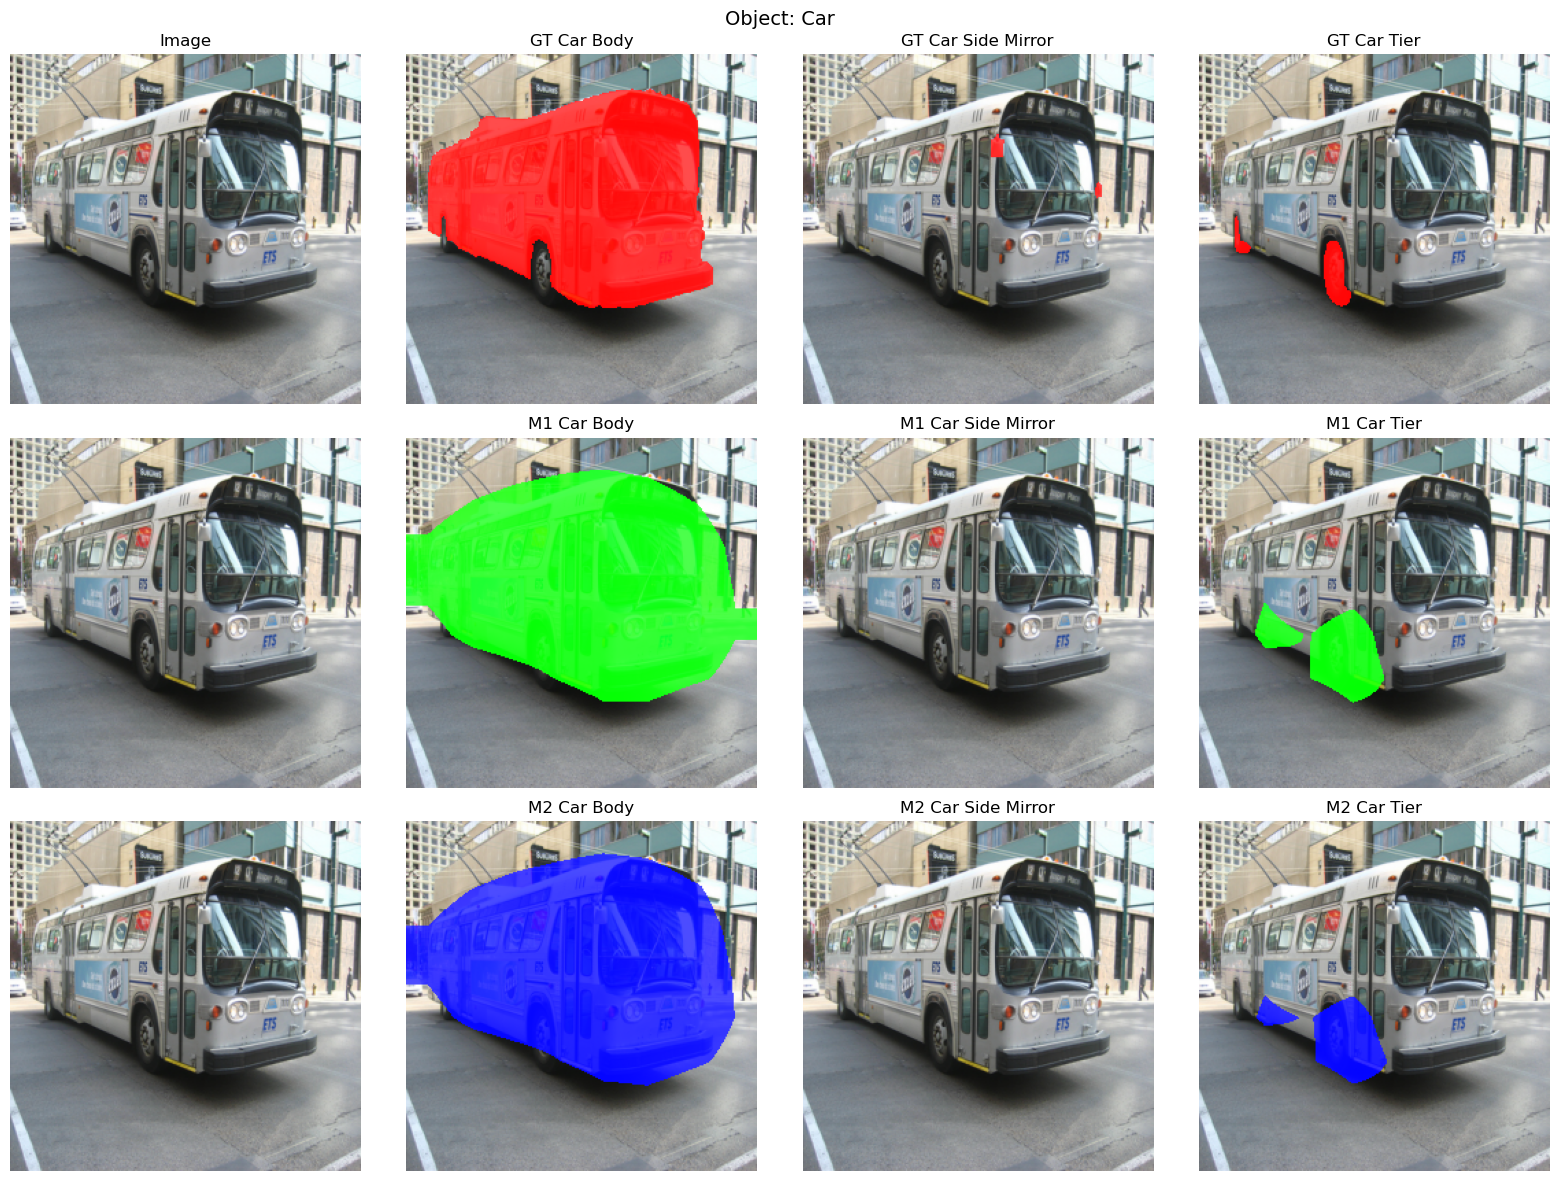

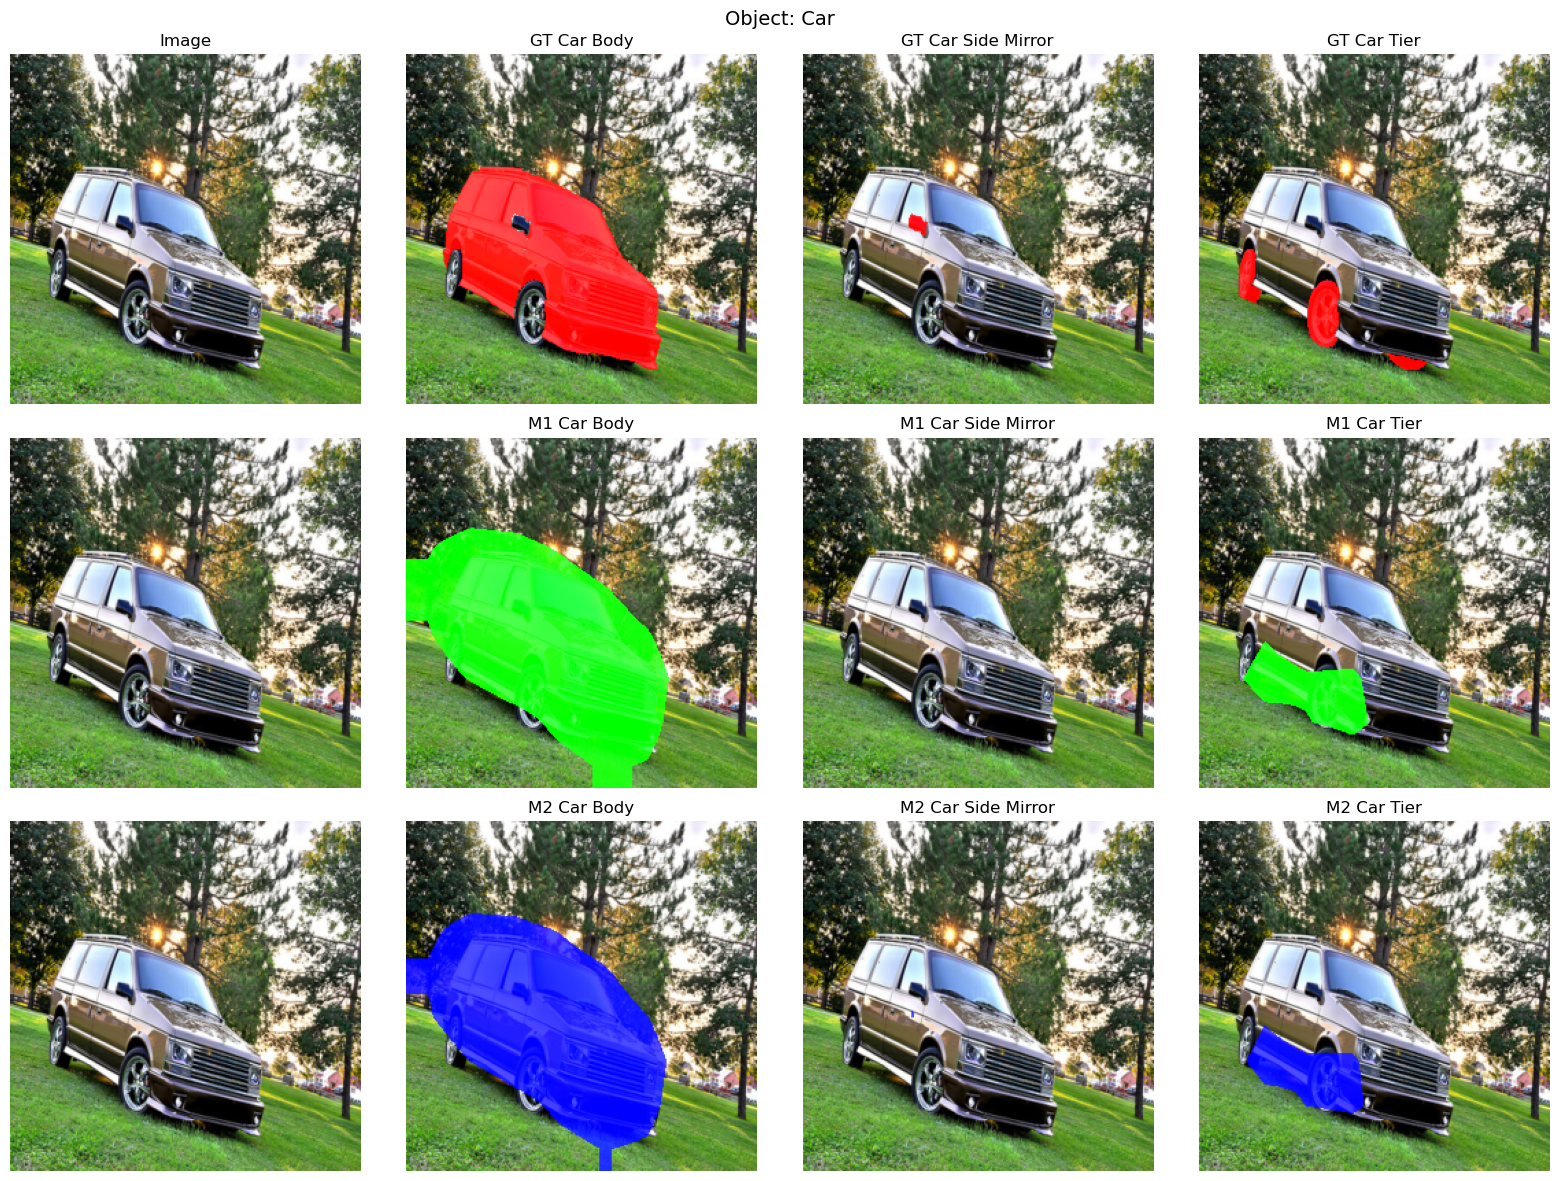

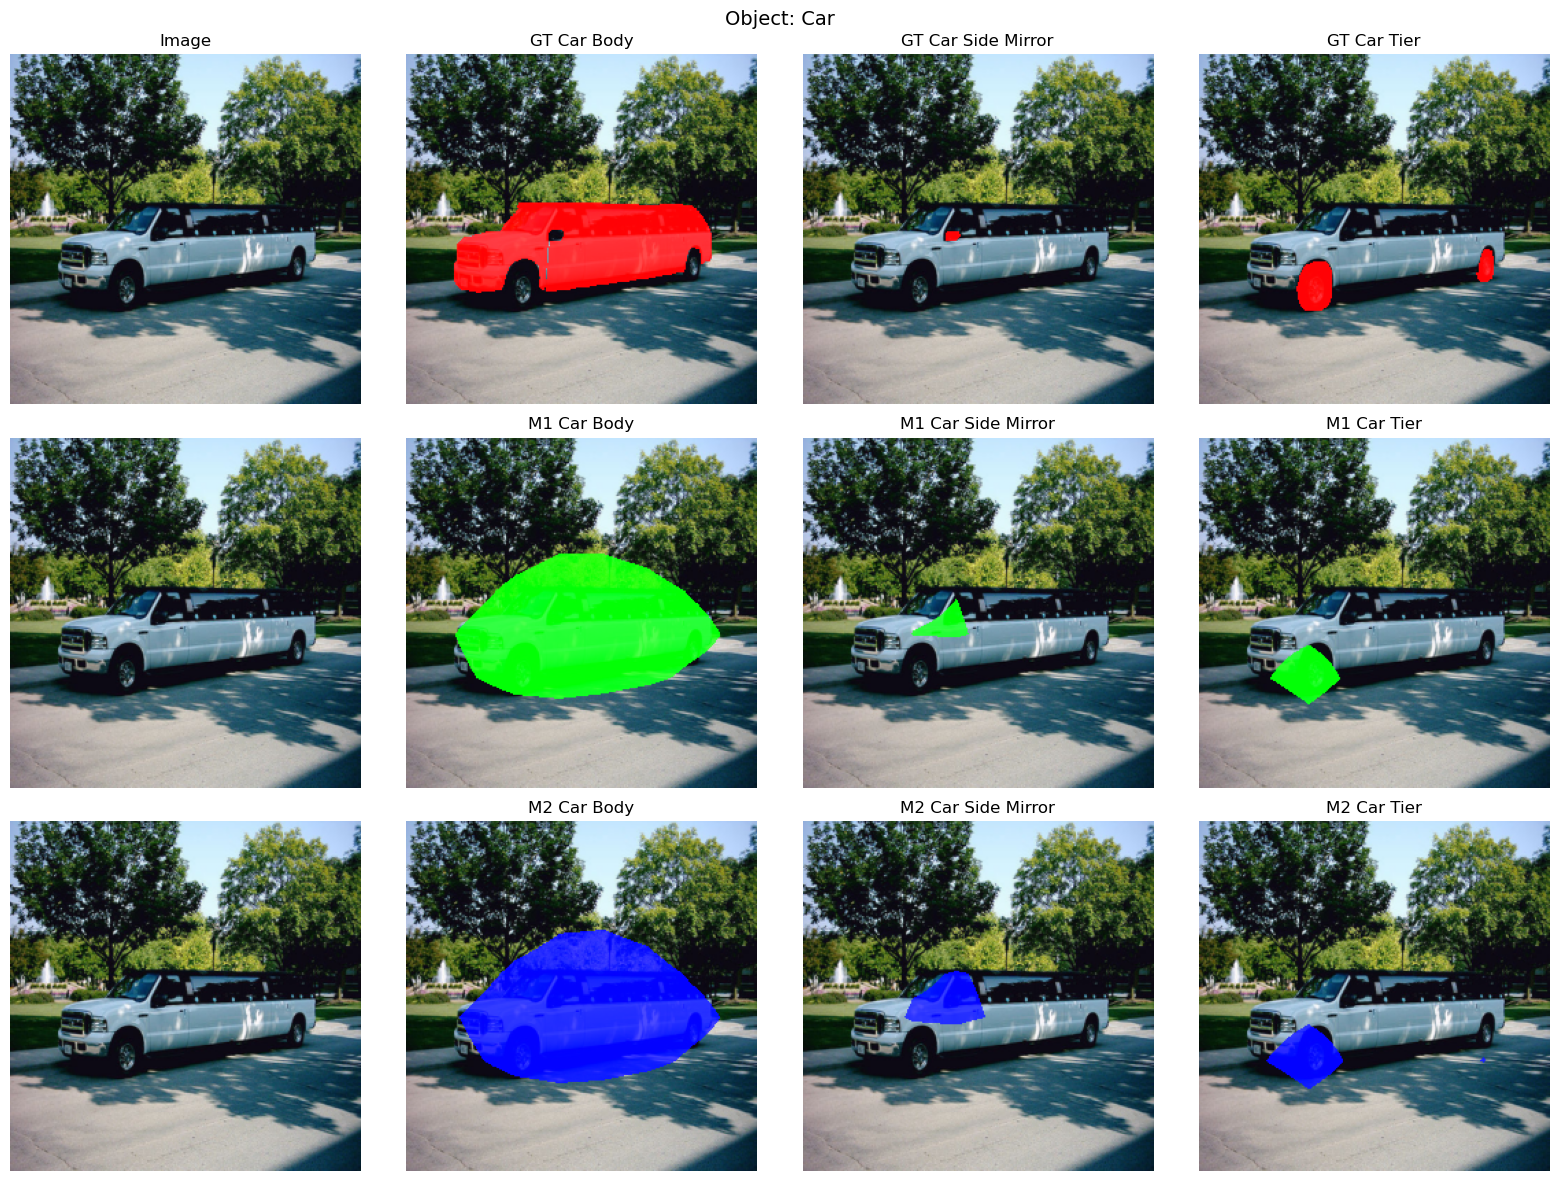

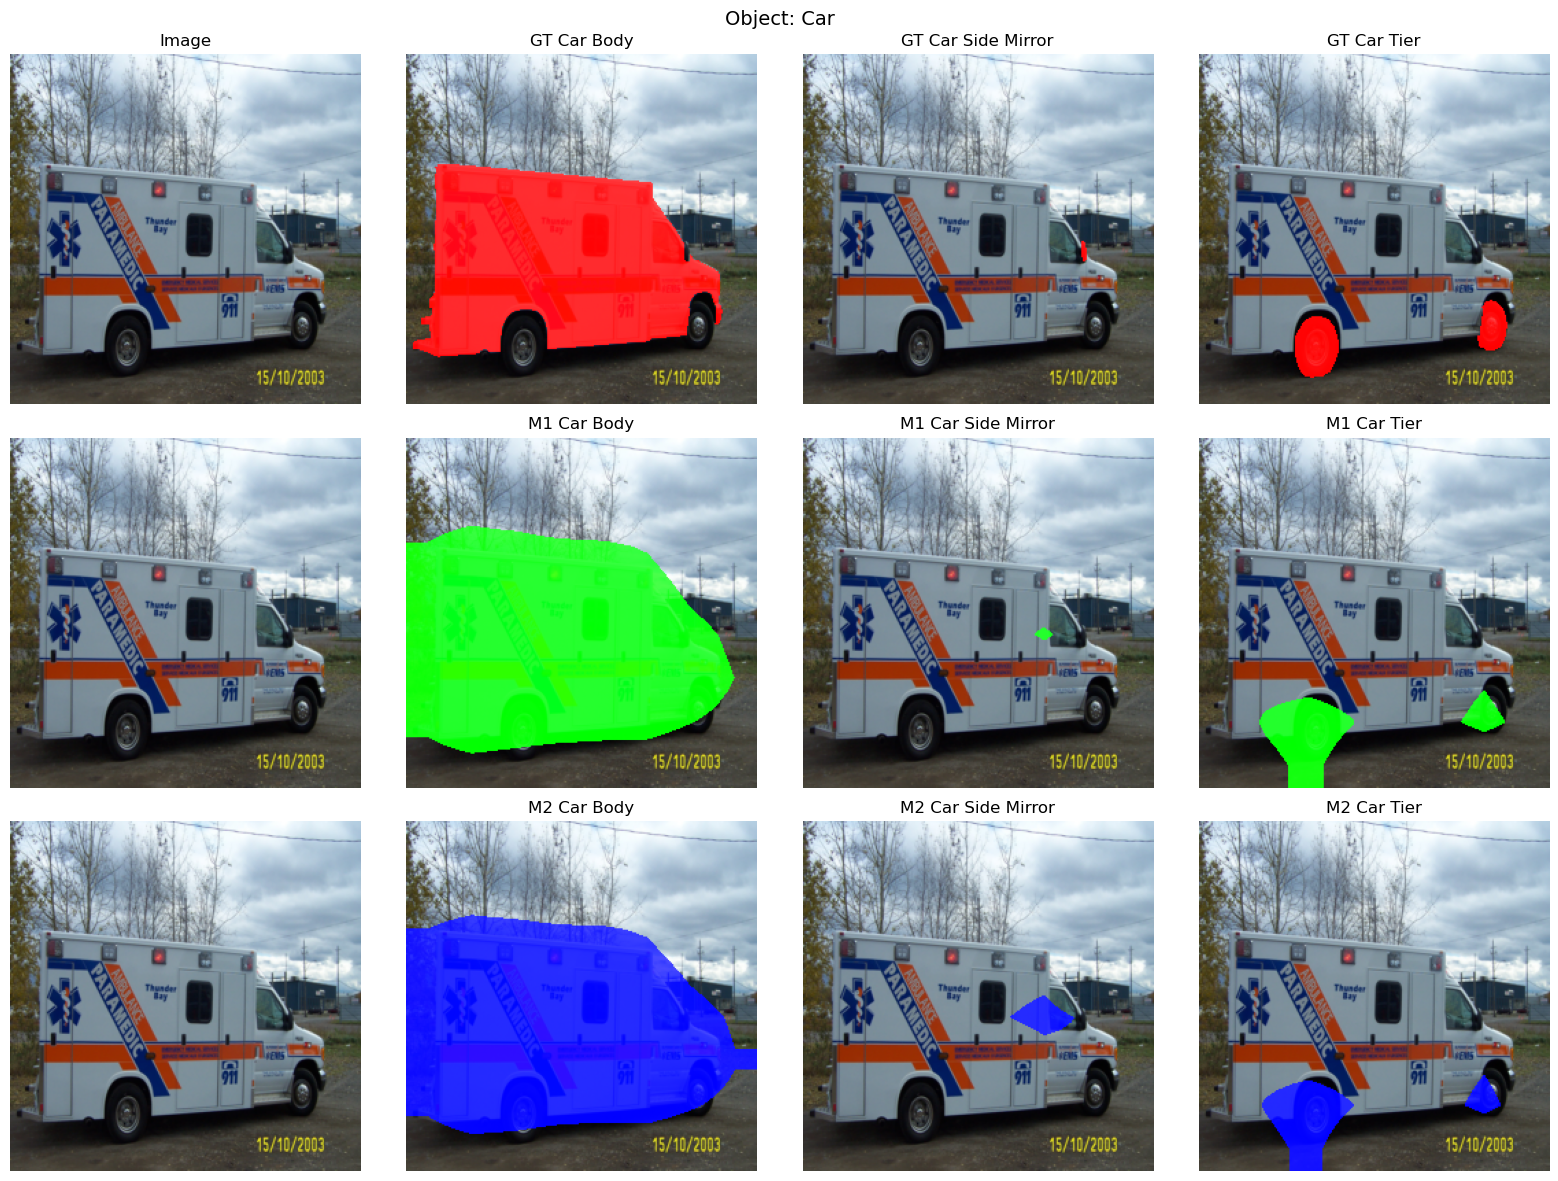

In [57]:
visualize_segmentation_gt_vs_models(
    model_M1,
    model_M2R,
    val_loader,
    CANONICAL_PARTS,
    device,
    num_images=4
)


In [58]:
import torch
import torch.nn.functional as F
import random

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ---------- 1.a. Simple block occlusion (center or random) ----------
def occlude_batch_blocks(images: torch.Tensor,
                         mode: str = "center",
                         block_frac: float = 0.3,
                         value: float = 0.0) -> torch.Tensor:
    """
    Apply simple rectangular occlusions to a batch of images.

    images: B x 3 x H x W
    mode: "center" or "random"
    block_frac: fraction of H and W to occlude (0.3 -> 30% of each dimension)
    value: fill value for masked pixels

    Returns:
      new_images: B x 3 x H x W
    """
    B, C, H, W = images.shape
    new_images = images.clone()

    block_h = int(H * block_frac)
    block_w = int(W * block_frac)
    block_h = max(1, min(H, block_h))
    block_w = max(1, min(W, block_w))

    for b in range(B):
        if mode == "center":
            top = (H - block_h) // 2
            left = (W - block_w) // 2
        elif mode == "random":
            top = random.randint(0, H - block_h)
            left = random.randint(0, W - block_w)
        else:
            raise ValueError(f"Unknown occlusion mode: {mode}")

        bottom = top + block_h
        right  = left + block_w

        new_images[b, :, top:bottom, left:right] = value

    return new_images


# ---------- 1.b. Part-targeted occlusion using GT masks (analysis only) ----------
def occlude_batch_by_part(batch,
                          part_name: str,
                          canonical_parts,
                          mode: str = "remove_part",
                          value: float = 0.0,
                          device=device):
    """
    Occlude regions defined by a GT part mask.

    batch: dict from DataLoader:
        {
          "image":      B x 3 x H x W,
          "part_masks": {part_name: B x 1 x H x W},
          "obj_label":  ...
        }
    part_name: e.g. "Car Body"
    mode:
      - "remove_part": zero out pixels where that part is present
      - "keep_part":   zero out everything except that part
    value: fill value for masked region

    Returns:
      images_occ: B x 3 x H x W
    """
    images = batch["image"].to(device)
    B, C, H, W = images.shape
    images_occ = images.clone()

    if part_name not in batch["part_masks"]:
        # no such part in this batch -> return original images
        return images_occ

    mask = batch["part_masks"][part_name].to(device)    # B x 1 x H x W
    mask_bin = (mask > 0.5).float()

    if mode == "remove_part":
        images_occ = images_occ * (1.0 - mask_bin) + value * mask_bin
    elif mode == "keep_part":
        images_occ = images_occ * mask_bin + value * (1.0 - mask_bin)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    return images_occ


Using device: cuda


In [59]:
# ---------- 2.a. Plain evaluation (already used for M1/M2) ----------
def eval_obj_model(model, loader, device=device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["obj_label"].to(device)

            out = model(images)
            logits = out["obj_logits"]
            loss = ce(logits, labels)

            bsz = labels.size(0)
            total_loss += loss.item() * bsz
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += bsz

    if total == 0:
        return 0.0, 0.0

    return total_loss / total, total_correct / total


# ---------- 2.b. Evaluation with generic occlusion ----------
def eval_obj_model_with_occlusion(model,
                                  loader,
                                  device=device,
                                  occlusion_fn=None,
                                  occlusion_kwargs=None):
    """
    Evaluate model under an occlusion transformation.

    occlusion_fn(images, **kwargs) -> occluded images

    If occlusion_fn is None, behaves like normal eval_obj_model.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    occlusion_kwargs = occlusion_kwargs or {}

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["obj_label"].to(device)

            if occlusion_fn is not None:
                images = occlusion_fn(images, **occlusion_kwargs)

            out = model(images)
            logits = out["obj_logits"]
            loss = ce(logits, labels)

            bsz = labels.size(0)
            total_loss += loss.item() * bsz
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += bsz

    if total == 0:
        return 0.0, 0.0

    return total_loss / total, total_correct / total


# ---------- 2.c. Evaluation with part-specific occlusion ----------
def eval_with_removed_part(model, loader, part_name, value=0.0, device=device):
    """
    Evaluate model when a specific part (by GT mask) is removed.

    Only images where that part exists are used in the metric.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            if part_name not in batch["part_masks"]:
                continue

            mask = batch["part_masks"][part_name]  # B x 1 x H x W
            # keep only images where this part has any pixels
            present_mask = (mask.view(mask.size(0), -1).sum(dim=1) > 0)
            if present_mask.sum() == 0:
                continue

            images   = batch["image"][present_mask].to(device)
            labels   = batch["obj_label"][present_mask].to(device)
            sub_mask = mask[present_mask]

            batch_sub = {
                "image": images,
                "obj_label": labels,
                "part_masks": {part_name: sub_mask},
            }

            images_occ = occlude_batch_by_part(
                batch_sub,
                part_name=part_name,
                canonical_parts=CANONICAL_PARTS,
                mode="remove_part",
                value=value,
                device=device,
            )

            out = model(images_occ)
            logits = out["obj_logits"]
            loss = ce(logits, labels)

            bsz = labels.size(0)
            total_loss += loss.item() * bsz
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += bsz

    if total == 0:
        return 0.0, 0.0

    return total_loss / total, total_correct / total


In [60]:
class ResNetGlobalBaseline(nn.Module):
    """
    Baseline using the SAME ResNetBackbone as M1/M2,
    but without parts or graph:
      image -> ResNetBackbone -> global pooled feature g -> classifier head
    """
    def __init__(self, num_classes: int):
        super().__init__()
        self.backbone = ResNetBackbone()        # same as in ModelM1/M2
        C = self.backbone.out_channels

        # freeze backbone (to match M1/M2 Stage 2)
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.head = nn.Sequential(
            nn.Linear(C, C),
            nn.ReLU(inplace=True),
            nn.Linear(C, num_classes),
        )

    def forward(self, images: torch.Tensor):
        F_sp, g = self.backbone(images)   # g: B x C
        logits = self.head(g)
        return {"obj_logits": logits}


In [61]:
def load_R0_from_checkpoint(ckpt_path: str, device=device):
    ckpt = torch.load(ckpt_path, map_location=device)
    num_classes = ckpt["num_classes"]
    model_R0 = ResNetGlobalBaseline(num_classes).to(device)
    model_R0.load_state_dict(ckpt["model_R0"])
    print("Loaded R0 from", ckpt_path)
    return model_R0

CKPT_R0 = "checkpoints_partgraph/resnet_global_R0.pth"  # <-- your path
model_R0 = load_R0_from_checkpoint(CKPT_R0, device=device)

# No occlusion baseline
for name, model in [("R0 global", model_R0),
                    ("M1 parts-only", model_M1),
                    ("M2R parts+graph", model_M2R)]:
    loss_clean, acc_clean = eval_obj_model(model, val_loader, device=device)
    print(f"{name:14s} | val (clean)  loss={loss_clean:.3f} acc={acc_clean:.3f}")

print("\n--- Center-block occlusion (60% of image) ---")
occ_kwargs = {"mode": "center", "block_frac": 0.6, "value": 0.0}

for name, model in [("R0 global", model_R0),
                    ("M1 parts-only", model_M1),
                    ("M2R parts+graph", model_M2R)]:
    loss_occ, acc_occ = eval_obj_model_with_occlusion(
        model,
        val_loader,
        device=device,
        occlusion_fn=occlude_batch_blocks,
        occlusion_kwargs=occ_kwargs,
    )
    print(f"{name:14s} | val (occ)    loss={loss_occ:.3f} acc={acc_occ:.3f}")


Loaded R0 from checkpoints_partgraph/resnet_global_R0.pth
R0 global      | val (clean)  loss=0.071 acc=0.976
M1 parts-only  | val (clean)  loss=0.131 acc=0.978
M2R parts+graph | val (clean)  loss=0.098 acc=0.979

--- Center-block occlusion (60% of image) ---
R0 global      | val (occ)    loss=1.118 acc=0.628
M1 parts-only  | val (occ)    loss=1.863 acc=0.610
M2R parts+graph | val (occ)    loss=1.581 acc=0.553


In [62]:
print("\n--- Random-block occlusion (60% width) ---")
occ_kwargs_rand = {"mode": "random", "block_frac": 0.6, "value": 0.0}

for name, model in [("R0 global", model_R0),
                    ("M1 parts-only", model_M1),
                    ("M2R parts+graph", model_M2R)]:
    loss_occ, acc_occ = eval_obj_model_with_occlusion(
        model,
        val_loader,
        device=device,
        occlusion_fn=occlude_batch_blocks,
        occlusion_kwargs=occ_kwargs_rand,
    )
    print(f"{name:14s} | val (rand)   loss={loss_occ:.3f} acc={acc_occ:.3f}")



--- Random-block occlusion (60% width) ---
R0 global      | val (rand)   loss=0.844 acc=0.723
M1 parts-only  | val (rand)   loss=1.307 acc=0.724
M2R parts+graph | val (rand)   loss=1.226 acc=0.666


In [63]:
part_to_remove = "Car Body"   # change to any canonical part name you want

print(f"\n--- Part-specific occlusion: remove '{part_to_remove}' ---")
for name, model in [("R0 global", model_R0),
                    ("M1 parts-only", model_M1),
                    ("M2 parts+graph", model_M2)]:
    loss_occ, acc_occ = eval_with_removed_part(
        model,
        val_loader,
        part_name=part_to_remove,
        value=0.0,
        device=device,
    )
    print(f"{name:14s} | val (no {part_to_remove}) acc={acc_occ:.3f}")



--- Part-specific occlusion: remove 'Car Body' ---
R0 global      | val (no Car Body) acc=0.842
M1 parts-only  | val (no Car Body) acc=0.860
M2 parts+graph | val (no Car Body) acc=0.851


In [64]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def _idx_to_obj_name(obj_name_to_idx):
    return {v: k for k, v in obj_name_to_idx.items()}

def _to_img_np(x):
    """x: 3xHxW tensor in [0,1] (your notebook uses Resize+ToTensor)"""
    img = x.detach().cpu().permute(1, 2, 0).numpy()
    # safety clamp
    img = np.clip(img, 0.0, 1.0)
    return img

def _overlay_mask_rgb(img_rgb, mask_hw, color="red"):
    """
    img_rgb: HxWx3 float in [0,1]
    mask_hw: HxW bool
    color: 'red'/'green'/'blue'
    """
    out = img_rgb.copy()
    if mask_hw.sum() == 0:
        return out

    if color == "red":
        out[mask_hw, 0] = 1.0
        out[mask_hw, 1] *= 0.3
        out[mask_hw, 2] *= 0.3
    elif color == "green":
        out[mask_hw, 1] = 1.0
        out[mask_hw, 0] *= 0.3
        out[mask_hw, 2] *= 0.3
    elif color == "blue":
        out[mask_hw, 2] = 1.0
        out[mask_hw, 0] *= 0.3
        out[mask_hw, 1] *= 0.3
    else:
        raise ValueError("color must be red/green/blue")
    return out

def _pred_text(logits, gt_idx, idx_to_name, topk=1):
    """
    logits: 1 x C
    returns short string for title
    """
    probs = torch.softmax(logits, dim=1)[0]
    pred_idx = int(probs.argmax().item())
    pred_name = idx_to_name.get(pred_idx, str(pred_idx))
    pred_conf = float(probs[pred_idx].item())
    gt_conf   = float(probs[int(gt_idx)].item())

    ok = (pred_idx == int(gt_idx))
    mark = "✓" if ok else "✗"
    return f"pred={pred_name} ({pred_conf:.2f}) {mark}\nP(gt)={gt_conf:.2f}"

@torch.no_grad()
def visualize_part_occlusion_eval(
    model_R0,
    model_M1,
    model_M2,
    loader,
    part_name: str,
    canonical_parts,
    obj_name_to_idx,
    device,
    num_images: int = 4,
    thresh: float = 0.5,
    occl_value: float = 0.0,
):
    """
    Shows per-image qualitative evaluation for part-specific occlusion.
    Layout per example: 2 rows (clean vs occluded) x 4 cols.

    Row 0 (clean):
      [0] clean + GT part overlay
      [1] clean + M1 predicted part overlay (+ M1 class pred)
      [2] clean + M2 predicted part overlay (+ M2 class pred)
      [3] clean (R0) (+ R0 class pred)

    Row 1 (occluded = remove GT part pixels):
      [0] occluded + (removed region overlay)
      [1] occluded + M1 predicted part overlay (+ M1 class pred)
      [2] occluded + M2 predicted part overlay (+ M2 class pred)
      [3] occluded (R0) (+ R0 class pred)
    """
    idx_to_name = _idx_to_obj_name(obj_name_to_idx)
    part_to_idx = {p: i for i, p in enumerate(canonical_parts)}
    if part_name not in part_to_idx:
        raise ValueError(f"part_name='{part_name}' not in CANONICAL_PARTS")

    k = part_to_idx[part_name]

    model_R0.eval()
    model_M1.eval()
    model_M2.eval()

    shown = 0

    for batch in loader:
        # batch keys in your notebook: image, part_masks (dict), obj_label, obj_name
        if "part_masks" not in batch:
            continue
        if part_name not in batch["part_masks"]:
            continue

        images = batch["image"]          # Bx3xHxW
        labels = batch["obj_label"]      # B
        obj_names = batch.get("obj_name", None)

        gt_masks = batch["part_masks"][part_name]  # Bx1xHxW

        # keep only samples where mask has pixels
        present = (gt_masks.view(gt_masks.size(0), -1).sum(dim=1) > 0)
        idxs = present.nonzero(as_tuple=False).view(-1).tolist()
        if len(idxs) == 0:
            continue

        for bi in idxs:
            # prepare single sample
            x_clean = images[bi:bi+1].to(device)     # 1x3xHxW
            y_gt    = labels[bi].to(device)          # scalar
            m_gt    = gt_masks[bi:bi+1].to(device)   # 1x1xHxW

            # pixel-level occlusion: remove the GT part region
            x_occ = x_clean * (1.0 - m_gt) + occl_value * m_gt  # broadcast over channels

            # forward passes: clean
            out_R0_clean = model_R0(x_clean)
            out_M1_clean = model_M1(x_clean)
            out_M2_clean = model_M2(x_clean)

            # forward passes: occluded
            out_R0_occ = model_R0(x_occ)
            out_M1_occ = model_M1(x_occ)
            out_M2_occ = model_M2(x_occ)

            # extract predicted mask probs for the selected part (M1/M2)
            m1_clean = torch.sigmoid(out_M1_clean["masks_logits"][0, k]).detach().cpu().numpy()
            m2_clean = torch.sigmoid(out_M2_clean["masks_logits"][0, k]).detach().cpu().numpy()
            m1_occ   = torch.sigmoid(out_M1_occ["masks_logits"][0, k]).detach().cpu().numpy()
            m2_occ   = torch.sigmoid(out_M2_occ["masks_logits"][0, k]).detach().cpu().numpy()

            # GT mask for overlay
            mgt_np = (m_gt[0, 0].detach().cpu().numpy() > 0.5)

            # images to numpy
            img_clean = _to_img_np(x_clean[0])
            img_occ   = _to_img_np(x_occ[0])

            # overlays
            clean_gt_overlay = _overlay_mask_rgb(img_clean, mgt_np, color="red")
            occ_gt_overlay   = _overlay_mask_rgb(img_occ,   mgt_np, color="red")

            m1_clean_overlay = _overlay_mask_rgb(img_clean, (m1_clean > thresh), color="green")
            m2_clean_overlay = _overlay_mask_rgb(img_clean, (m2_clean > thresh), color="blue")
            m1_occ_overlay   = _overlay_mask_rgb(img_occ,   (m1_occ   > thresh), color="green")
            m2_occ_overlay   = _overlay_mask_rgb(img_occ,   (m2_occ   > thresh), color="blue")

            # titles
            gt_name = None
            if obj_names is not None:
                gt_name = obj_names[bi]
            else:
                gt_name = idx_to_name.get(int(y_gt.item()), str(int(y_gt.item())))

            tR0_clean = _pred_text(out_R0_clean["obj_logits"], y_gt, idx_to_name)
            tM1_clean = _pred_text(out_M1_clean["obj_logits"], y_gt, idx_to_name)
            tM2_clean = _pred_text(out_M2_clean["obj_logits"], y_gt, idx_to_name)

            tR0_occ = _pred_text(out_R0_occ["obj_logits"], y_gt, idx_to_name)
            tM1_occ = _pred_text(out_M1_occ["obj_logits"], y_gt, idx_to_name)
            tM2_occ = _pred_text(out_M2_occ["obj_logits"], y_gt, idx_to_name)

            # figure: 2 rows x 4 cols
            fig, axes = plt.subplots(2, 4, figsize=(18, 8))

            # Row 0: clean
            axes[0, 0].imshow(clean_gt_overlay)
            axes[0, 0].set_title(f"CLEAN + GT mask\nGT={gt_name}\nPart={part_name}")
            axes[0, 0].axis("off")

            axes[0, 1].imshow(m1_clean_overlay)
            axes[0, 1].set_title(f"M1 CLEAN\n{tM1_clean}")
            axes[0, 1].axis("off")

            axes[0, 2].imshow(m2_clean_overlay)
            axes[0, 2].set_title(f"M2 CLEAN\n{tM2_clean}")
            axes[0, 2].axis("off")

            axes[0, 3].imshow(img_clean)
            axes[0, 3].set_title(f"R0 CLEAN\n{tR0_clean}")
            axes[0, 3].axis("off")

            # Row 1: occluded
            axes[1, 0].imshow(occ_gt_overlay)
            axes[1, 0].set_title(f"OCCLUDED (remove GT {part_name})")
            axes[1, 0].axis("off")

            axes[1, 1].imshow(m1_occ_overlay)
            axes[1, 1].set_title(f"M1 OCCLUDED\n{tM1_occ}")
            axes[1, 1].axis("off")

            axes[1, 2].imshow(m2_occ_overlay)
            axes[1, 2].set_title(f"M2 OCCLUDED\n{tM2_occ}")
            axes[1, 2].axis("off")

            axes[1, 3].imshow(img_occ)
            axes[1, 3].set_title(f"R0 OCCLUDED\n{tR0_occ}")
            axes[1, 3].axis("off")

            plt.tight_layout()
            plt.show()

            shown += 1
            if shown >= num_images:
                return


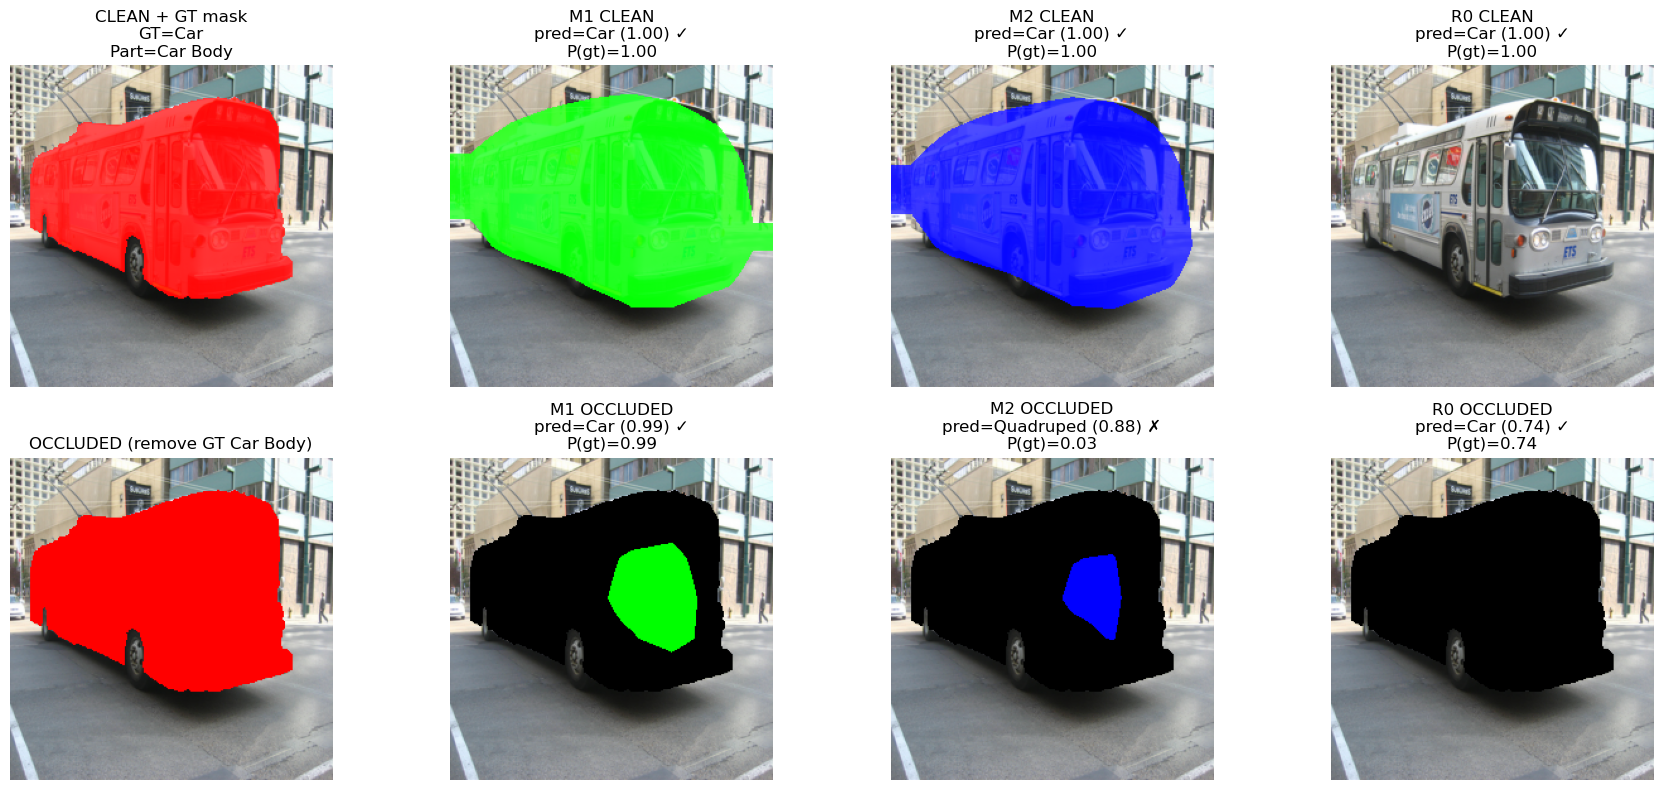

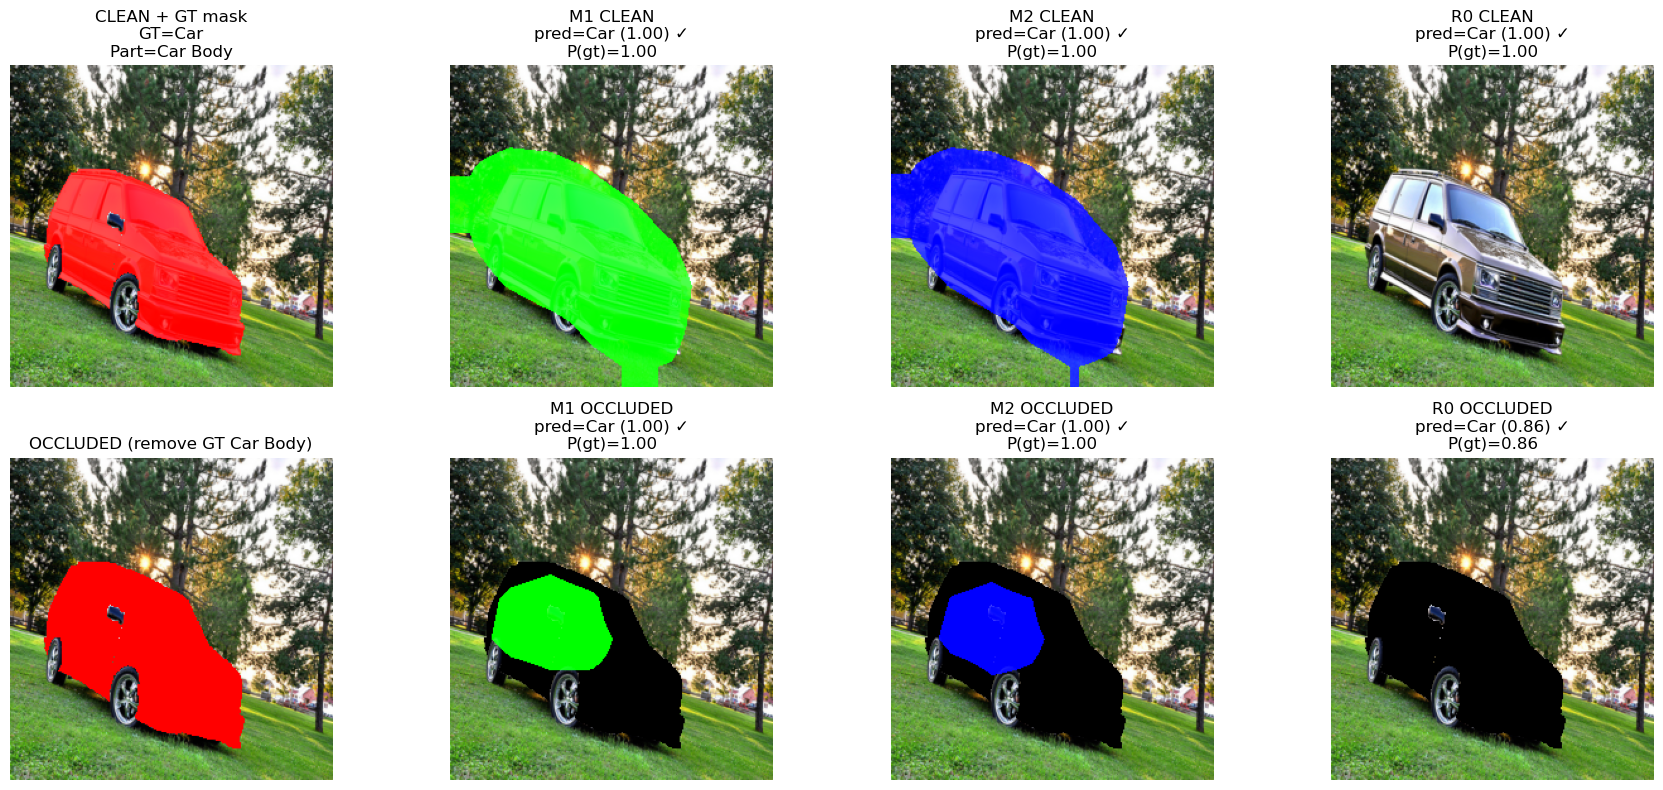

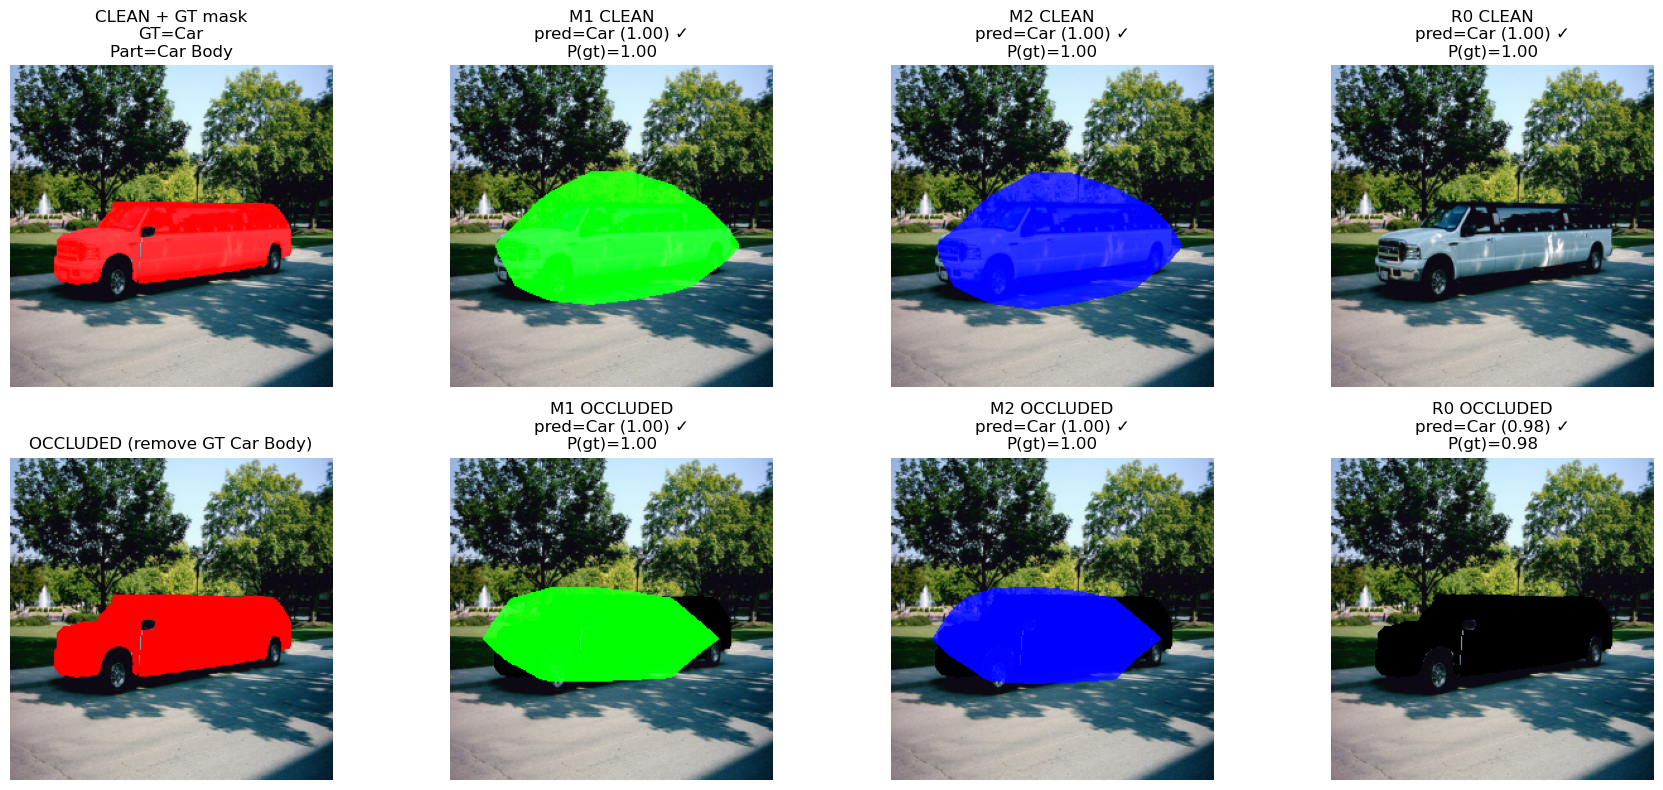

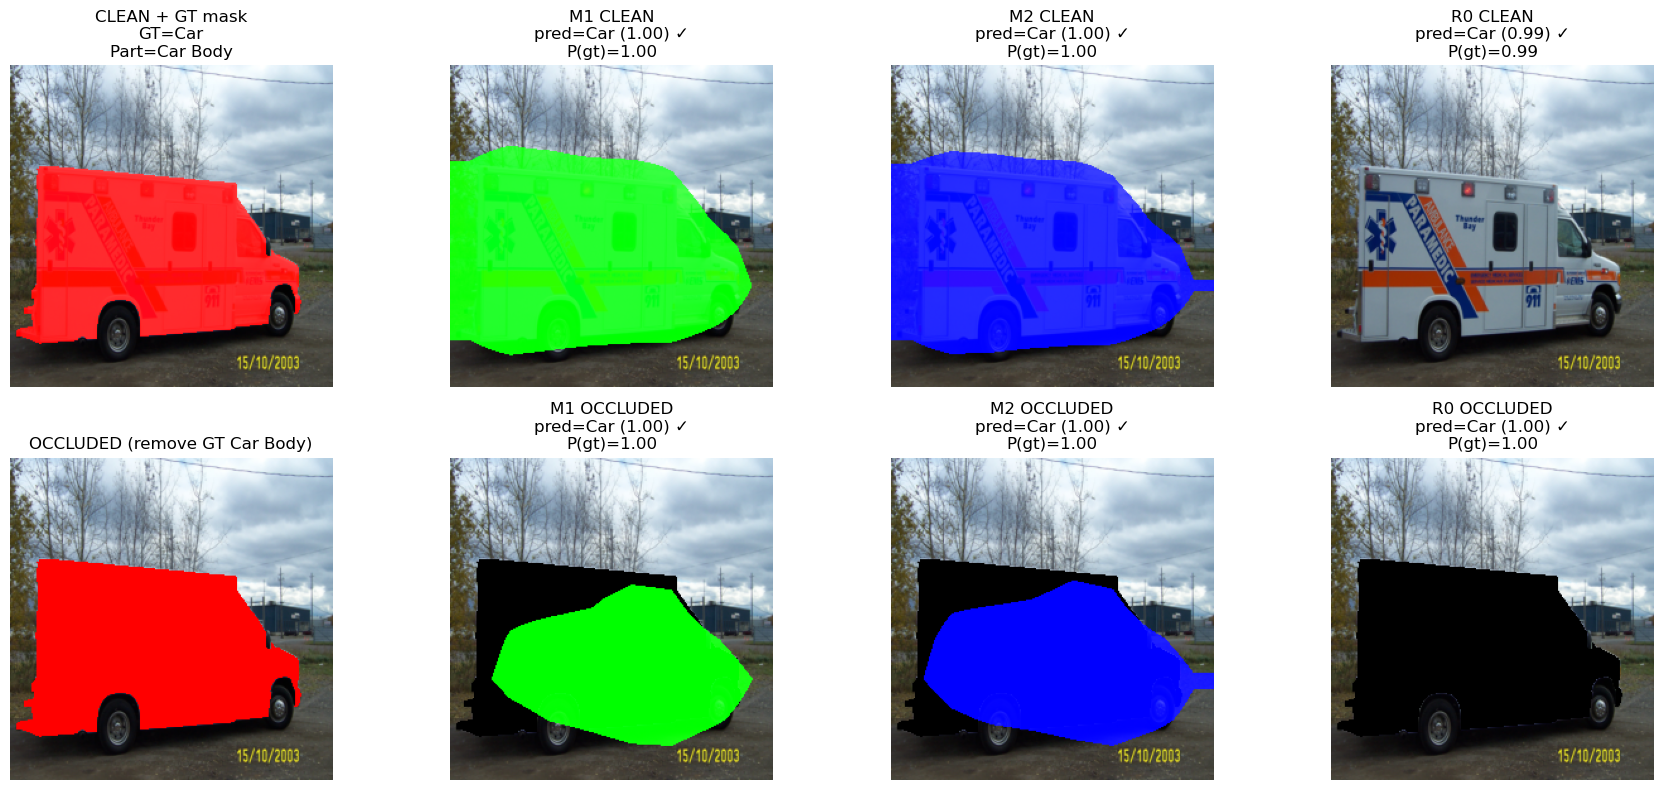

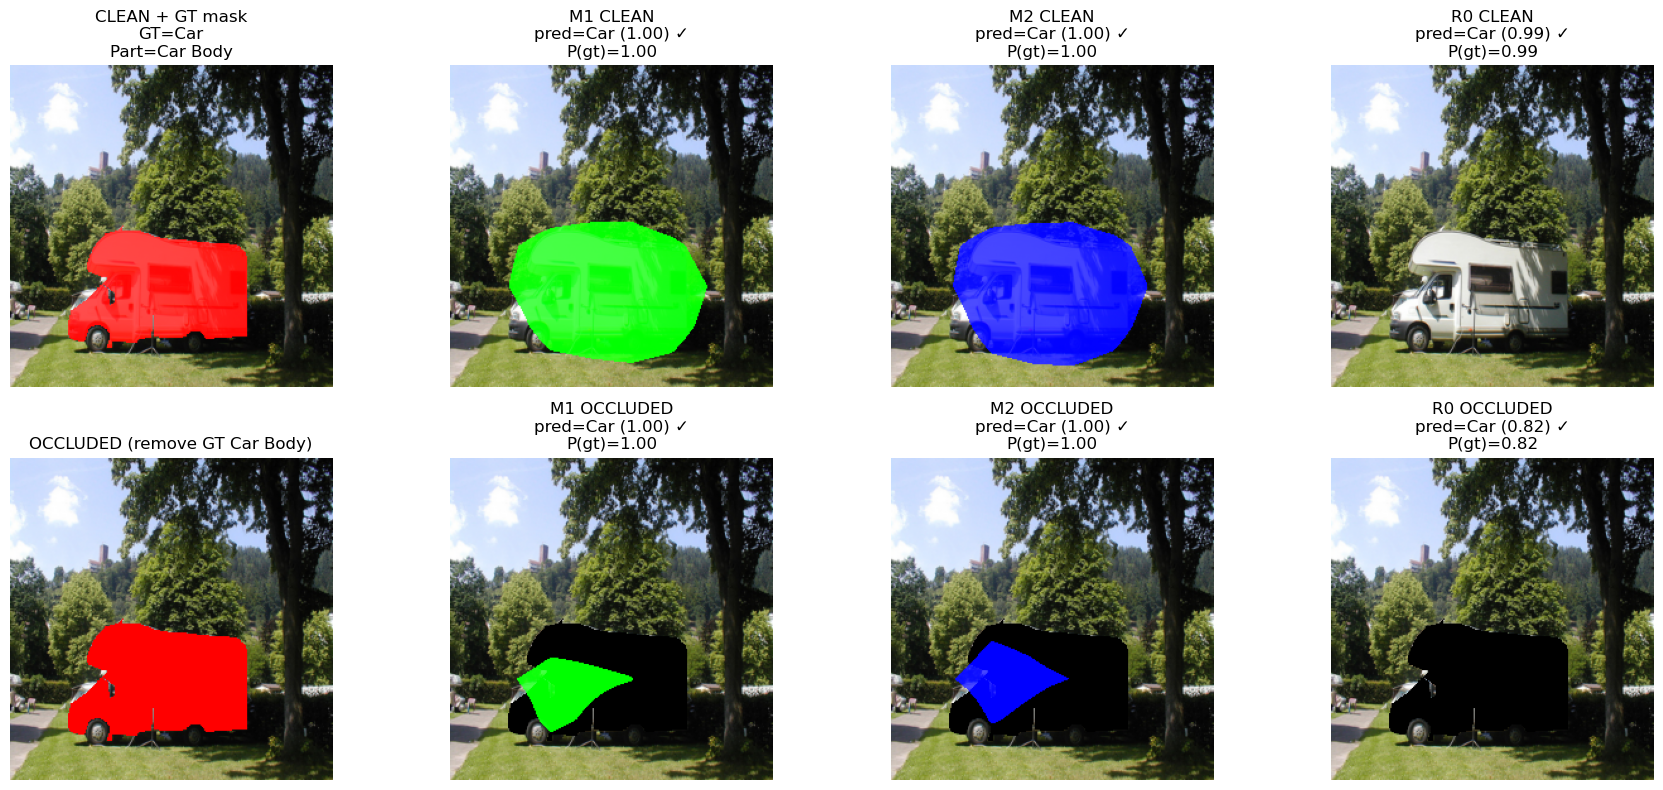

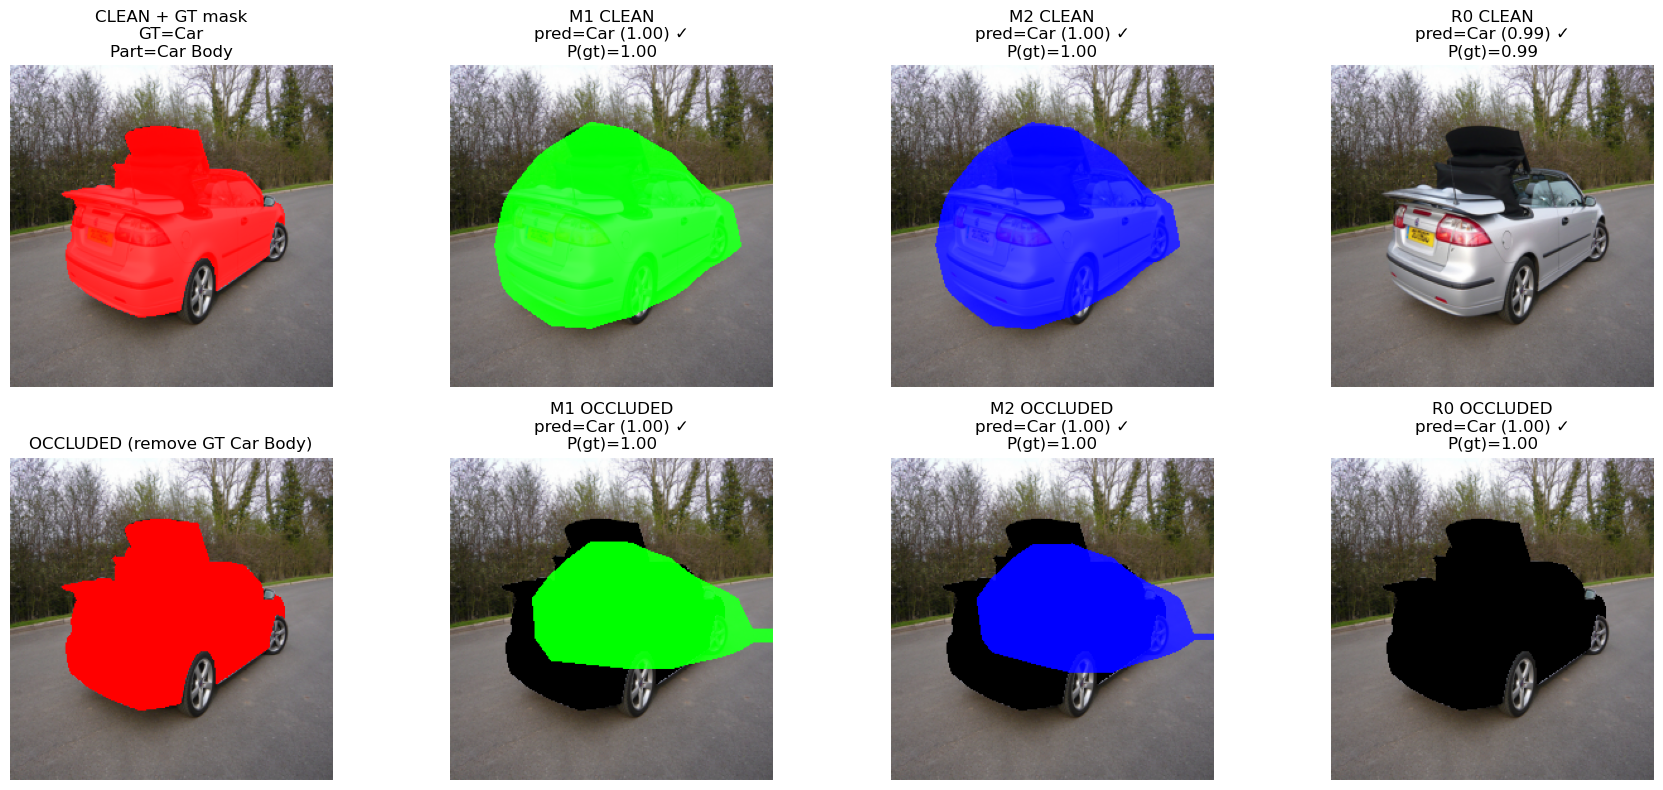

In [65]:
part_to_remove = "Car Body"
visualize_part_occlusion_eval(
    model_R0, model_M1, model_M2,
    val_loader,
    part_name=part_to_remove,
    canonical_parts=CANONICAL_PARTS,
    obj_name_to_idx=OBJ_NAME_TO_IDX,
    device=device,
    num_images=6,
    thresh=0.5,
    occl_value=0.0
)
